# **Modeling learning curves in the Two-Armed Bandit task**

## **Authors**
- **Franka Böckmann**  
- **Ewa Godlewska**  
- **Iheb Marouani**  
- **Julian Calvin Rill**  
- **David Raul Carranza Navarrete**

## **Introduction**
This notebook analyzes human decision-making in the **Two-Armed Bandit Task**, a classic reinforcement learning problem where participants repeatedly choose between two options (bandits) to maximize their rewards.

### **Experiment and Data Collection**
We collected real behavioral data using an online **Two-Armed Bandit experiment** ([available here](https://snamazova.github.io/two_armed_bandit_task/bandit.html)).  
The experiment involved **11 participants** making **100 sequential choices**, with a **reward probability reversal** occurring at **trial 50**.

### **Modeling Approach**
We compare two reinforcement learning models to explain participant behavior:
1. **Rescorla-Wagner Model (RWM):** A simple model that updates expected rewards based on past outcomes.
2. **Bayesian Reinforcement Model (Thompson Sampling) (BRM):** A model that uses probability distributions to model uncertainty and decision making.

### **Objective**
- Compare how well the **Rescorla-Wagner** and **Bayesian models** fit participants' behavior.
- Analyze **learning curves** in real behavioral data: How participants improve their choices over time as they learn which bandit is more rewarding.
- Visualize learning patterns and model performance.
---

Next, let's start by loading and preprocessing the data.


# **Data Loading**

We load the data from 11 participants, which we have gathered outselves. This data is stored in a public Google Drive folder.

In [ ]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import json
import os
import glob

We upladed json files with participant's data onto a public google drive folder and are accessing it using gdown library

In [ ]:
import gdown

folder_id = "1_XB3rsUJxl-17Uv3L4l10I2LRReZLN1p"
!gdown --folder https://drive.google.com/drive/folders/1_XB3rsUJxl-17Uv3L4l10I2LRReZLN1p -O /content/json_files

Retrieving folder contents
Processing file 15ufjyhKRW33AgrjYdJjT2bEx1ydnugI0 2armed_bandit_atryle.json
Processing file 1eNahxkUQqE-9lxy80ILzMDQhTbTkYWty 2armed_bandit_chekli.json
Processing file 1FrZ_S-eluPo4w9khqXgkHu_pJBPjvyPX 2armed_bandit_Chi.json
Processing file 1qSe-O96AaLaIZiwhmGspY4iGxF1qtd7x 2armed_bandit_ciinz.json
Processing file 1OKfa25Mtt0emoSmyN_PWq7vLyJyh1Pl9 2armed_bandit_db.json
Processing file 1c9ZouyphcErVUmB4IEhQUEhPknmaCCUb 2armed_bandit_ha.json
Processing file 1l1-cKDc9yaLhvSO_RGKUPw2s9UdfQeEU 2armed_bandit_julian_1.json
Processing file 1bAsQjR5huHli1O3pbRAwQDoZlIUfz4V- 2armed_bandit_zuss.json
Processing file 1MuXdExAbLYTuyvJHQJ1gkLRY2jbhcB83 2armed_bandit-2.json
Processing file 155b2rDVI3lmWg7ugI3mW0TvGmpMYVGJD 2armed_bandit.json
Processing file 1ssjnefeD8T25jHVIWU6QE1YcbExpmD_0 2armed_banditFranka.json
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=15ufj

# **Data Cleaning**

In this code block, we load the different JSON files for all participants, read their data, and convert it into a structured DataFrame. We clean the data by removing unnecessary prefixes from column names, filtering out instruction trials, and ensuring no duplicate columns exist. We extract key variables: trial index, choice, and reward, and assign a participant ID based on the filename. Trials are sorted in the correct order, and a stay column is computed to track whether participants repeated their previous choice. The cleaned data is then stored for merging in later steps.

In [ ]:
import os
import json
import pandas as pd
import glob

# Set the folder path where JSON files are stored
folder_path = "/content/json_files"

# Get all JSON files
file_list = glob.glob(os.path.join(folder_path, "*.json"))

# Load and merge all JSON files
all_data = []
for file in file_list:
    with open(file, "r") as f:
        data = json.load(f)

    df = pd.DataFrame(data)

    # Rename columns to remove "bean_" prefix
    df.rename(columns=lambda x: x.replace("bean_", ""), inplace=True)

    # Remove instruction trials and ensure a full copy
    df = df.dropna(subset=["bandits"]).copy()

    # Drop duplicate 'value' column if it exists
    df = df.loc[:, ~df.columns.duplicated()]

    # Ensure required columns exist after duplicate removal
    if "value" not in df.columns:
        print(f"Skipping {file}: 'value' column is missing after duplicate removal")
        continue

    # Keep only relevant columns
    df = df[["trial_index", "response", "value"]]

    # Rename for consistency
    df.columns = ["trial", "choice", "reward"]

    # Ensure correct data format
    df["choice"] = pd.to_numeric(df["choice"], errors="coerce").fillna(-1).astype(int)
    df["reward"] = pd.to_numeric(df["reward"], errors="coerce").fillna(0).astype(int)

    # Add participant ID from filename
    df["participant_id"] = os.path.basename(file).split(".")[0]

    # Sort data to ensure correct trial order
    df = df.sort_values(by=["participant_id", "trial"])

    # Store cleaned data
    all_data.append(df)

# Merge datasets
if not all_data:
    raise ValueError("No valid JSON files found. Check file structure!")

# Concatenate all data into a single DataFrame
full_dataset = pd.concat(all_data, ignore_index=True)

# Normalize trial numbers for each participant (start from 1 to 100)
full_dataset["trial"] = full_dataset.groupby("participant_id").cumcount() + 1

# Reorder columns to: participant_id, trial, choice, reward, stay
full_dataset = full_dataset[["participant_id", "trial", "choice", "reward"]]

# Display first rows
print(full_dataset)

# Save the updated dataset without the index column
full_dataset.to_csv("/content/merged_dataset.csv", index=False)

              participant_id  trial  choice  reward
0           2armed_bandit_db      1       0       0
1           2armed_bandit_db      2       1       1
2           2armed_bandit_db      3       1       1
3           2armed_bandit_db      4       1       0
4           2armed_bandit_db      5       0       0
...                      ...    ...     ...     ...
1095  2armed_bandit_julian_1     96       1       1
1096  2armed_bandit_julian_1     97       1       1
1097  2armed_bandit_julian_1     98       1       0
1098  2armed_bandit_julian_1     99       1       0
1099  2armed_bandit_julian_1    100       0       1

[1100 rows x 4 columns]


# **Data Visualisation for first Inspection**



In this code block, we preprocess the data for plotting, ensuring the computation of key behavioral metrics, which can be reused later for analysis and visualization. This is also for us to inspect the data.

- **Choice probabilities for Bandit 1**  
  - Computed as the proportion of trials where `choice == 0` for each trial:

- **Running average cumulative reward**  
  - Calculated as the cumulative sum of rewards up to each trial, divided by the trial number:

- **Rolling stay probabilities**  
  - Computed by checking whether the choice on a given trial matches the previous trial’s choice, then calculating the mean stay probability for Bandit 1 and Bandit 2 under rewarded and unrewarded conditions.  


- **Total choice probabilities before and after reversal**  
  - Computed as the mean probability of choosing each bandit separately for trials **before** and **after** the reversal trial:




In [ ]:
import pandas as pd
import numpy as np

def preprocess_df_for_plotting(df, window_size=10, reversal_trial=50, stay_window=10):
    """
    Preprocesses the raw bandit dataframe for plotting.

    Parameters:
        df (pd.DataFrame): DataFrame with columns "participant_id", "trial", "choice", and "reward".
        window_size (int): Window size for computing rolling averages for choice and reward.
        reversal_trial (int): Trial number at which the reversal occurs.
        stay_window (int): Rolling window size for smoothing the stay probabilities.

    Returns:
        aggregated (pd.DataFrame): DataFrame with columns:
            - "trial": The trial number.
            - "p_bandit1": Probability of choosing Bandit 1 per trial.
            - "rolling_mean_choice": Rolling average of choosing Bandit 1.
            - "rolling_mean_reward": Rolling average of reward.
            - "running_average_reward": Cumulative average of rewards (NO window size).
        rolling_stay_probs (dict): Rolling stay probabilities for different conditions.
        choice_prob_df (pd.DataFrame): Before vs. after reversal choice probabilities.
        reversal_trial (int): The reversal trial.
        window_size (int): The window size used for rolling averages.
        stay_window (int): The window size used for rolling stay probabilities.
    """
    # -------------------------
    # Compute **Total Choice Probability Per Trial**
    aggregated = df.groupby("trial").agg({"reward": "mean"}).reset_index()

    # Compute probability of choosing Bandit 1 (choice == 0) for each trial
    aggregated["p_bandit1"] = df.groupby("trial")["choice"].apply(lambda x: (x == 0).mean())

    # Compute rolling averages
    aggregated["rolling_mean_choice"] = aggregated["p_bandit1"].rolling(window=window_size, min_periods=1).mean()
    aggregated["rolling_mean_reward"] = aggregated["reward"].rolling(window=window_size, min_periods=1).mean()

    # Compute running (cumulative) average reward **WITHOUT WINDOW SIZE**
    aggregated["running_average_reward"] = aggregated["reward"].cumsum() / np.arange(1, len(aggregated) + 1)

    # -------------------------
    #  Compute Rolling Stay Probabilities
    df_sorted = df.sort_values(by=["participant_id", "trial"]).copy()

    # Compute the "stay" indicator
    df_sorted["stay"] = df_sorted.groupby("participant_id")["choice"].diff() == 0
    df_sorted["stay"] = df_sorted["stay"].astype(int)

    # Compute previous reward and previous choice for each participant
    df_sorted["previous_reward"] = df_sorted.groupby("participant_id")["reward"].shift(1)
    df_sorted["previous_choice"] = df_sorted.groupby("participant_id")["choice"].shift(1)

    # Compute stay probabilities grouped by trial
    stay_prob_B1_rewarded = df_sorted[(df_sorted["previous_choice"] == 0) & (df_sorted["previous_reward"] == 1)] \
                              .groupby("trial")["stay"].mean()
    stay_prob_B1_unrewarded = df_sorted[(df_sorted["previous_choice"] == 0) & (df_sorted["previous_reward"] == 0)] \
                              .groupby("trial")["stay"].mean()
    stay_prob_B2_rewarded = df_sorted[(df_sorted["previous_choice"] == 1) & (df_sorted["previous_reward"] == 1)] \
                              .groupby("trial")["stay"].mean()
    stay_prob_B2_unrewarded = df_sorted[(df_sorted["previous_choice"] == 1) & (df_sorted["previous_reward"] == 0)] \
                              .groupby("trial")["stay"].mean()

    # Apply rolling mean for smoothing
    rolling_stay_probs = {
        "B1_rewarded": stay_prob_B1_rewarded.rolling(window=stay_window, min_periods=1).mean(),
        "B1_unrewarded": stay_prob_B1_unrewarded.rolling(window=stay_window, min_periods=1).mean(),
        "B2_rewarded": stay_prob_B2_rewarded.rolling(window=stay_window, min_periods=1).mean(),
        "B2_unrewarded": stay_prob_B2_unrewarded.rolling(window=stay_window, min_periods=1).mean()
    }

    # -------------------------
    # Compute Choice Probabilities Before and After Reversal
    choice_prob_B1_before = df[df["trial"] <= reversal_trial].groupby("trial")["choice"].apply(lambda x: (x == 0).mean()).mean()
    choice_prob_B2_before = df[df["trial"] <= reversal_trial].groupby("trial")["choice"].apply(lambda x: (x == 1).mean()).mean()

    choice_prob_B1_after  = df[df["trial"] > reversal_trial].groupby("trial")["choice"].apply(lambda x: (x == 0).mean()).mean()
    choice_prob_B2_after  = df[df["trial"] > reversal_trial].groupby("trial")["choice"].apply(lambda x: (x == 1).mean()).mean()

    choice_prob_df = pd.DataFrame({
        "Bandit 1": [choice_prob_B1_before, choice_prob_B1_after],
        "Bandit 2": [choice_prob_B2_before, choice_prob_B2_after]
    }, index=["Before Reversal", "After Reversal"])

    return aggregated, rolling_stay_probs, choice_prob_df, reversal_trial, window_size, stay_window

In this codeblock, we define the behavioural plots as calculated above.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_behaviour(df, window_size=10, reversal_trial=50, stay_window=10):
    """
    Preprocesses the dataframe and creates a multi-plot figure showing:
      1. Rolling average choice probability (Bandit 1)
      2. Running average reward (Cumulative Mean)
      3. Rolling stay probabilities for Bandit 1 and Bandit 2 under rewarded and unrewarded conditions
      4. Grouped bar plot for choice probabilities before vs. after reversal.

    Parameters:
        df (pd.DataFrame): DataFrame with columns "participant_id", "trial", "choice", "reward", etc.
        window_size (int): Window size for computing rolling averages for choice and reward.
        reversal_trial (int): Trial number at which the reversal occurs.
        stay_window (int): Rolling window size for smoothing the stay probabilities.
    """
    # Preprocess the data using our previously defined function.
    aggregated, rolling_stay_probs, choice_prob_df, reversal_trial, window_size, stay_window = \
        preprocess_df_for_plotting(df, window_size=window_size, reversal_trial=reversal_trial, stay_window=stay_window)

    # Create multi-plot figure with 4 subplots
    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    # Plot 1: Evolution of choice probabilities (Bandit 1 in blue)
    axes[0].plot(aggregated["trial"], aggregated["rolling_mean_choice"], label="Rolling Choice Prob. (Bandit 1)", color="blue", lw=2)
    axes[0].axvline(reversal_trial, color="black", linestyle="--", label="Reversal Point")
    axes[0].axhline(0.5, color='red', linestyle="--", label="Chance Level")
    axes[0].set_xlabel("Trial")
    axes[0].set_ylabel("Probability")
    axes[0].set_title("Rolling Choice Probabilities")
    axes[0].legend()

    # Plot 2: Running average cumulative reward
    axes[1].plot(aggregated["trial"], aggregated["running_average_reward"], linestyle="-", color="blue", lw=1.5, label="Cumulative Avg. Reward")
    axes[1].axvline(reversal_trial, color="black", linestyle="--", label="Reversal Point")
    axes[1].set_xlabel("Trial")
    axes[1].set_ylabel("Cumulative Avg. Reward")
    axes[1].set_title("Running Average Reward (Cumulative)")
    axes[1].legend()

    # Plot 3: Rolling stay probabilities
    axes[2].plot(rolling_stay_probs["B1_rewarded"].index, rolling_stay_probs["B1_rewarded"], linestyle="-", color="blue", lw=2, label="Stay (B1, Rewarded)")
    axes[2].plot(rolling_stay_probs["B1_unrewarded"].index, rolling_stay_probs["B1_unrewarded"], linestyle="dotted", color="blue", lw=2, label="Stay (B1, Unrewarded)")
    axes[2].plot(rolling_stay_probs["B2_rewarded"].index, rolling_stay_probs["B2_rewarded"], linestyle="-", color="orange", lw=2, label="Stay (B2, Rewarded)")
    axes[2].plot(rolling_stay_probs["B2_unrewarded"].index, rolling_stay_probs["B2_unrewarded"], linestyle="dotted", color="orange", lw=2, label="Stay (B2, Unrewarded)")
    axes[2].axvline(reversal_trial, color="black", linestyle="--", label="Reversal Point")
    axes[2].set_xlabel("Trial")
    axes[2].set_ylabel("Stay Probability")
    axes[2].set_title(f"Rolling Stay Probabilities\n(Window={stay_window})")
    axes[2].legend()

    # Plot 4: Grouped bar plot for choice probabilities before vs. after reversal
    choice_prob_df.plot(kind="bar", ax=axes[3], color=["#4c72b0", "#dd8452"], alpha=0.9, edgecolor="black", width=0.8)
    axes[3].set_ylabel("Choice Probability")
    axes[3].set_title("Choice Probabilities\nBefore vs. After Reversal")
    axes[3].set_xticklabels(choice_prob_df.index, rotation=0)
    axes[3].set_ylim(0, 1)
    axes[3].legend(["Bandit 1", "Bandit 2"], title="Bandit")

    plt.tight_layout()
    plt.show()


In this code block, we call the behavior plotting function to have a first look at the data.

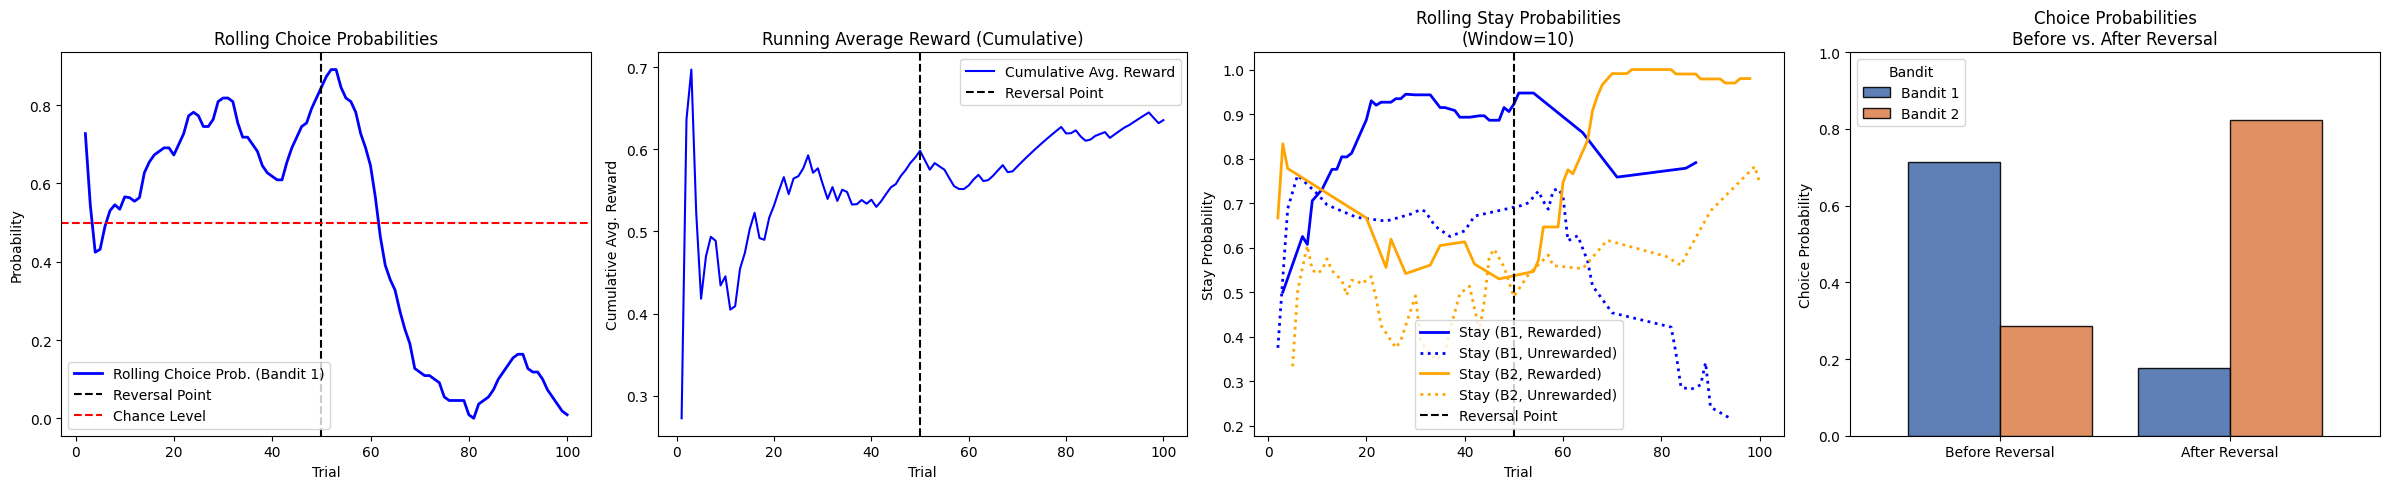

In [ ]:
plot_behaviour(full_dataset)

## DataFrame Structure Overview

The DataFrame(df) contains multiple columns representing various aspects of a **two-armed bandit experiment**. Below is a breakdown of the key columns:  

## 1. General Trial Information  
- **`trial_index`**: The index of the current trial in the experiment (note: displaying the score is also considered a trial, as it is a stimulus).  
- **`trial_type`**: The type of trial, indicating how the response was made (e.g., via keyboard or mouse click).  
- **`time_elapsed`**: The total time elapsed (in milliseconds) since the start of the experiment.  
- **`internal_node_id`**: An internal identifier for the trial structure.  

## 2. Response and Stimulus Data  
- **`stimulus`**: The presented stimulus for the trial (a `<div>` tag containing the value and color of the bandit).  
- **`response`**: The participant’s response/input during the trial.  
- **`rt`**: The reaction time (in milliseconds) taken to respond.  

## 3. Task-Specific Information (Bean Task)    
- **`bean_trial_duration`**: The duration of the bean trial.  
- **`bean_duration`**: The time the bean stimulus was displayed.  
- **`bean_stimulus`**: The presented stimulus for the trial (a `<div>` tag containing the value and color of the bandit).  
- **`bean_choices`**: The available choice options in the trial.  
- **`bean_correct_key`**: The correct key (button press) for the task.  
- **`bean_type`**: The category of the bean stimulus.  
- **`bean_text`**: A text representation of the bean (if applicable).  
- **`bean_color`**: The color of the bean, which may be relevant to decision-making.  
- **`bean_correct`**: A boolean or categorical value indicating whether the response was correct.  
  - *Note:* In the bandit task, there is no strictly correct choice, as the task focuses on exploration rather than accuracy.  
- **`bean_value`**: The assigned value or reward associated with the bean (bandit).  
- **`bean_score`**: The accumulated score in the experiment.  

## 4. Additional Processing Data  
- **`bean_html_array`**: An HTML representation of the bean stimulus.  
- **`bean_values`**: An array containing value-related information for different beans.  
- **`bean_time_after_response`**: The time elapsed after the participant’s response.  
- **`bean_bandits`**: Information about Bandit 1 and Bandit 2 (their color and value).  


# **1. Model Implementation**

## **1.1. Rescorla-Wagner Model (model-free agent)**


### **Implementing and simulating data from models that are suitable to test our hypothesis.**



This code block implements a **softmax function** used for action selection in reinforcement learning. The softmax function takes an array of Q-values (estimates of expected reward for each action) and an inverse temperature parameter, β, as inputs. The parameter β controls how deterministic the action selection is: a high β makes the selection process more greedy (favoring the highest Q-value), while a low β adds more randomness, promoting exploration. To improve numerical stability and prevent overflow issues, the code subtracts the maximum value from the Q-values before exponentiation. The function returns a probability distribution over the actions that sums to one.

In [ ]:
# Step 1: Define Softmax

import numpy as np

def softmax(vals, beta):
    """
    Softmax function for action selection.
    :param vals: Array of Q-values for actions.
    :param beta: Inverse temperature parameter (higher beta → more deterministic).
    :return: Probability distribution over actions.
    """
    vals = np.array(vals)
    exp_vals = np.exp(beta * (vals - np.max(vals)))  # Prevents overflow
    probabilities = exp_vals / np.sum(exp_vals)
    return probabilities

This code block implements the **Rescorla-Wagner update rule**, which is a simple model for learning from feedback. The function takes the current Q-values for both actions (bandits), the chosen action, the reward received, and the learning rate (α) as inputs. It then updates the Q-value for the selected action by adding a fraction (determined by the learning rate) of the prediction error (the difference between the received reward and the current Q-value). The updated Q-values reflect the agent's new estimate of the expected rewards based on recent experience.

In [ ]:
# Step 2: Rescorla Wagner update

def rescorla_wagner_update(Q_values, action, reward, alpha):
    """
    Update the Q-value for the selected action using the Rescorla-Wagner rule.

    :param Q_values: Current Q-values for both bandits.
    :param action: Chosen action (0 or 1).
    :param reward: Received reward (0 or 1).
    :param alpha: Learning rate.
    :return: Updated Q-values.
    """
    Q_values[action] = Q_values[action] + alpha * (reward - Q_values[action])
    return Q_values

This code block below explains the **RescorlaWagnerAgent** class, which models an agent using the Rescorla-Wagner learning rule to estimate the expected rewards of two actions (bandits). The agent makes decisions using a softmax function, allowing for probabilistic action selection.

**Key Components:**

- **Initialization:**  
  - The agent starts with two parameters:  
    - **$\alpha$ (alpha):** The learning rate, which determines how much new information updates the Q-values.  
    - **$\beta$ (beta):** The inverse temperature parameter, which controls the balance between exploration and exploitation in decision-making.  
  - Initial Q-values are set to `[0.5, 0.5]`, representing the agent’s initial belief about the expected rewards of the two bandits (no preference).

- **Action Selection:**  
  - The agent uses a **softmax function** to compute action probabilities, ensuring that higher-valued actions are chosen more often while still allowing exploration. The probability of selecting action $a$ is given by:

    $$
    P(a) = \frac{e^{\beta Q(a)}}{\sum_{b} e^{\beta Q(b)}}
    $$

  - The method `get_action_probabilities()` applies this softmax function to the agent’s current Q-values.

- **Q-value Update:**  
  - When an action is chosen and a reward is received, the agent updates its Q-values using the **Rescorla-Wagner learning rule**:

    $$
    Q_{t+1}(a) = Q_t(a) + \alpha \left(R_t - Q_t(a)\right)
    $$

  - Here, $Q_t(a)$ is the current estimate of the value of action $a$, and $R_t$ is the received reward. The update is proportional to the prediction error $(R_t - Q_t(a))$.

- **Simulation Process:**  
  - The agent runs a series of trials where:
    1. It computes action probabilities using softmax.
    2. It selects an action based on these probabilities.
    3. It receives a reward, determined by predefined reward probabilities.
    4. It updates its Q-values based on the received reward.
    5. It records the chosen action, received reward, and updated Q-values.

  - A **reversal occurs at trial 50**, meaning that the reward probabilities for the two bandits swap. This tests the agent’s ability to adapt to environmental changes.


This class encapsulates the essential learning and decision-making processes of a simple reinforcement learning model, enabling simulations of how an agent learns and adapts over time.


In [ ]:
class RescorlaWagnerAgent:
    def __init__(self, alpha, beta):
        self.alpha = alpha  # Learning rate
        self.beta = beta  # Softmax inverse temperature
        self.Q_values = np.array([0.5, 0.5])  # Initial Q-values

    def get_action_probabilities(self):
        """Computes Softmax probabilities over actions using your existing function."""
        return softmax(self.Q_values, self.beta)

    def update_q_values(self, action, reward):
        """Updates Q-values using your existing Rescorla-Wagner update function."""
        self.Q_values = rescorla_wagner_update(self.Q_values, action, reward, self.alpha)

    def simulate(self, n_trials=100):
        """
        Runs the Rescorla-Wagner agent for a number of trials and returns choices and rewards.
        """
        choices = []
        rewards = []
        Q_history = []

        # Define reward probabilities
        reward_probs = [0.8, 0.2]  # Initial reward probabilities

        for t in range(n_trials):
            # Reverse reward probabilities at trial 50
            if t == 50:
                reward_probs = [0.2, 0.8]  # Swap probabilities

            # Choose an action using Softmax
            action_probs = self.get_action_probabilities()
            action = np.random.choice([0, 1], p=action_probs)  # Sample action

            # Get reward based on chosen action's probability
            reward = 1 if np.random.rand() < reward_probs[action] else 0

            # Update Q-values using the Rescorla-Wagner rule
            self.update_q_values(action, reward)

            # Store results
            choices.append(action)
            rewards.append(reward)
            Q_history.append(self.Q_values.copy())

        return np.array(choices), np.array(rewards), np.array(Q_history)



## **1.2. Bayesian Reinforcement Learning Model (model based agent)**



This class implements a Bayesian reinforcement learning model (BRM), which helps an agent learn to choose between two options (bandits) based on rewards. It does so by maintaining beliefs about reward probabilities using a Beta distribution, updating these beliefs after each choice, and making decisions using a softmax function.

**Belief Updates (Beta Distribution):**  
Each bandit has a success count $\alpha$ and failure count $\beta$. The expected reward probability is:  

$$
\mu = \frac{\alpha}{\alpha + \beta}
$$  

After a choice $a_t$ with reward $r_t \in \{0,1\}$, the update rule is:  

$$
\alpha_{a_t} \leftarrow (1 - h) (\alpha_{a_t} + r_t) + h \alpha_0
$$  
$$
\beta_{a_t} \leftarrow (1 - h) (\beta_{a_t} + (1 - r_t)) + h \beta_0
$$  

where $h$ is the **hazard rate**, controlling forgetting. The unchosen bandit's values drift toward the prior.  

**Decision Making (Softmax Choice Rule):**  
The probability of choosing bandit $a$ is given by:  

$$
P(a) = \frac{e^{\beta Q(a)}}{\sum_{b} e^{\beta Q(b)}}
$$  

where $Q(a) = \mu_a \cdot \text{inv_temp}$, and **inverse temperature** $\beta$ controls choice randomness.  

In [ ]:
class BayesianRLModel:
  def __init__(self, prior_alpha=1, prior_beta=1, inv_temp=5.0, hazard_rate=0.05):
    """
    Class for the Bayesian reinforcement learning model

    Parameters:
    - prior_alpha, prior_beta: parameters of the beta prior
    - inv_temp: inverse temperature for the softmax decision rule
    - hazard_rate: hazard rate for change-point detection
    """
    self.prior_alpha = prior_alpha
    self.prior_beta = prior_beta
    self.inv_temp = inv_temp
    self.hazard_rate = hazard_rate

    # initialize alpha and beta parameters for two bandits (beta distribution)
    self.alpha = {0: self.prior_alpha, 1: self.prior_alpha} # number of successes (rewards)
    self.beta = {0: self.prior_beta, 1: self.prior_beta} # number of failures (non-rewards)

    # to record the history over trials
    self.history = {
      'trial': [],
      'alpha0': [],
      'beta0': [],
      'alpha1': [],
      'beta1': [],
      'mu0': [],
      'mu1': [],
      'var0': [],
      'var1': [],
      'p_choice0': [],
      'p_choice1': []
    }

  def softmax(self, x):
    """Compute softmax values for an array x."""
    exp_x = np.exp(x - np.max(x))
    return exp_x / exp_x.sum()

  def update_beliefs(self, choice, reward):
    """
    Update the Beta parameters for the chosen bandit based on reward,
    and update the non-chosen bandit's beliefs by drifting them toward the prior.
    """
    # update the chosen bandit's belief based on the reward received
    updated_alpha = self.alpha[choice] + reward
    updated_beta = self.beta[choice] + (1 - reward)

    # apply hazard rate to allow forgetting of past information
    self.alpha[choice] = (1 - self.hazard_rate) * updated_alpha + self.hazard_rate * self.prior_alpha
    self.beta[choice] = (1 - self.hazard_rate) * updated_beta + self.hazard_rate * self.prior_beta

    # drift the non-chosen bandit's beliefs towards the prior
    non_chosen = 1 - choice
    self.alpha[non_chosen] = (1 - self.hazard_rate) * self.alpha[non_chosen] + self.hazard_rate * self.prior_alpha
    self.beta[non_chosen] = (1 - self.hazard_rate) * self.beta[non_chosen] + self.hazard_rate * self.prior_beta

  def compute_values(self):
    """
    Compute expected reward (mu) and uncertainty (variance) for each bandit,
    based on the current Beta parameters.
    """
    # expected reward (mean of beta distribution)
    mu0 = self.alpha[0] / (self.alpha[0] + self.beta[0])
    mu1 = self.alpha[1] / (self.alpha[1] + self.beta[1])

    # uncertainty (variance of beta distribution)
    var0 = (self.alpha[0] * self.beta[0]) / ((self.alpha[0] + self.beta[0])**2 * (self.alpha[0] + self.beta[0] + 1))
    var1 = (self.alpha[1] * self.beta[1]) / ((self.alpha[1] + self.beta[1])**2 * (self.alpha[1] + self.beta[1] + 1))

    return (mu0, mu1), (var0, var1)

  def compute_choice_probabilities(self, mu):
    """
    Compute choice probabilities using a softmax function.
    """
    # compute decision values (Q-values) for each bandit
    Qs = np.array([mu[0], mu[1]]) * self.inv_temp
    return self.softmax(Qs)

  def record_history(self, trial_idx, mu, var, probs):
    """Record the current state in the history dictionary."""
    self.history['trial'].append(trial_idx)
    self.history['alpha0'].append(self.alpha[0])
    self.history['beta0'].append(self.beta[0])
    self.history['alpha1'].append(self.alpha[1])
    self.history['beta1'].append(self.beta[1])
    self.history['mu0'].append(mu[0])
    self.history['mu1'].append(mu[1])
    self.history['var0'].append(var[0])
    self.history['var1'].append(var[1])
    self.history['p_choice0'].append(probs[0])
    self.history['p_choice1'].append(probs[1])

  def reset(self):
    """Resets the alpha, beta, and history to their initial values."""
    self.alpha = {0: self.prior_alpha, 1: self.prior_alpha}
    self.beta = {0: self.prior_beta, 1: self.prior_beta}
    for key in self.history:
      self.history[key] = []

  def get_history_df(self):
    """Return the recorded history as a pandas DataFrame."""
    return pd.DataFrame(self.history)

# **2. Model Simulation**

## **2.1. RWM Simulation**

### **Simulating data from both model for a single set of parameters. The simulation should mimic the experiment you are trying to model.**



This code block explains the **simulation of multiple participants** using the **Rescorla-Wagner** agent. It runs a reinforcement learning model across multiple participants, records their choices, rewards, and learning progression, and stores the results in a structured DataFrame.

**Key Steps:**

- **Simulation Setup:**
  - The number of participants (`n_participants`) and trials (`n_trials`) are defined.
  - Learning rate **$\alpha$** (how much new information updates Q-values) and inverse temperature **$\beta$** (controls exploration vs. exploitation) are set.
  - ​We selected α = 0.1 and β = 2.0 to simulate realistic learning behaviors. These parameters align with those used in similar reinforcement learning studies, such as the one by Haines (2017), which explores human choice and reinforcement learning.
- **Running the Model:**
  - A `RescorlaWagnerAgent` is created for each participant.
  - The agent undergoes `n_trials` of decision-making, receiving rewards based on probabilistic outcomes.
  - The agent's choices, rewards, and Q-value updates are stored.

- **Data Storage and Formatting:**
  - The choices and rewards of all participants are stored in flattened NumPy arrays for easy processing.
  - Q-values are stored in a 3D array of shape `(n_participants, n_trials, 2)`, where the last dimension represents Q-values for the two bandits.

- **Creating a DataFrame (`simulated_df_RWM`):**
  - Each trial is indexed from 1 to 100 for each participant.
  - The DataFrame contains:
    - `"participant_id"`: Identifies each participant.
    - `"trial"`: The trial number (1–100).
    - `"choice"`: The bandit choice (0 or 1).
    - `"reward"`: Whether the participant received a reward (0 or 1).
    - `"Q_Value_Bandit1"`: The estimated value of Bandit 1 at each trial.
    - `"Q_Value_Bandit2"`: The estimated value of Bandit 2 at each trial.

- **Output:**
  - The first 10 choices and rewards of the first participant are printed.
  - The first few rows of the full dataset are displayed.

This DataFrame serves as the foundation for analyzing learning behavior, choice patterns, and reward adaptation over time.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate behavior using the Rescorla-Wagner agent for multiple participants
n_participants = 11
n_trials = 100  # Total number of trials in the simulation
alpha = 0.1     # Learning rate
beta = 2.0      # Inverse temperature parameter for Softmax

# Storage for all participants
all_choices = []
all_rewards = []
all_Q_histories = []
participant_ids = []

# Run the model for each participant
for p in range(n_participants):
    # Create an agent instance
    agent = RescorlaWagnerAgent(alpha=alpha, beta=beta)

    # Run simulation
    sim_choices, sim_rewards, sim_Q_history = agent.simulate(n_trials=n_trials)

    # Store results
    all_choices.append(sim_choices)
    all_rewards.append(sim_rewards)
    all_Q_histories.append(sim_Q_history)
    participant_ids.extend([p] * n_trials)

# Convert lists to numpy arrays for easier processing
all_choices = np.array(all_choices).flatten()  # Shape: (11*100,)
all_rewards = np.array(all_rewards).flatten()  # Shape: (11*100,)
all_Q_histories = np.array(all_Q_histories)  # Shape: (11, 100, 2)

# Ensure trials are indexed from 1 to 100 for each participant
simulated_df_RWM = pd.DataFrame({
    "participant_id": participant_ids,
    "trial": np.concatenate([np.arange(1, n_trials + 1) for _ in range(n_participants)]),  # Start trials at 1
    "choice": all_choices,
    "reward": all_rewards,
    "Q_Value_Bandit1": all_Q_histories[:, :, 0].flatten(),
    "Q_Value_Bandit2": all_Q_histories[:, :, 1].flatten()
})

# Print out the first few simulated choices and rewards
print("Simulated choices (first 10 trials of participant 1):",
      simulated_df_RWM[simulated_df_RWM["participant_id"] == 0]["choice"][:10].values)

print("Simulated rewards (first 10 trials of participant 1):",
      simulated_df_RWM[simulated_df_RWM["participant_id"] == 0]["reward"][:10].values)

# Display the first few rows of the DataFrame
print(simulated_df_RWM)





Simulated choices (first 10 trials of participant 1): [1 0 1 0 0 1 1 1 1 1]
Simulated rewards (first 10 trials of participant 1): [0 1 0 1 1 0 0 1 0 0]
      participant_id  trial  choice  reward  Q_Value_Bandit1  Q_Value_Bandit2
0                  0      1       1       0         0.500000         0.450000
1                  0      2       0       1         0.550000         0.450000
2                  0      3       1       0         0.550000         0.405000
3                  0      4       0       1         0.595000         0.405000
4                  0      5       0       1         0.635500         0.405000
...              ...    ...     ...     ...              ...              ...
1095              10     96       1       1         0.443420         0.888618
1096              10     97       1       0         0.443420         0.799756
1097              10     98       1       0         0.443420         0.719780
1098              10     99       0       0         0.399078        

In the following code block, we call the functions as they are for later plotting, in the exact same way as we did with the real human data initial visualizations, but this time using the model-generated data. Additionally, we plot the Q-Values for the Rescorla-Wagner Model to examine how the behavior evolved from the model's learned values.

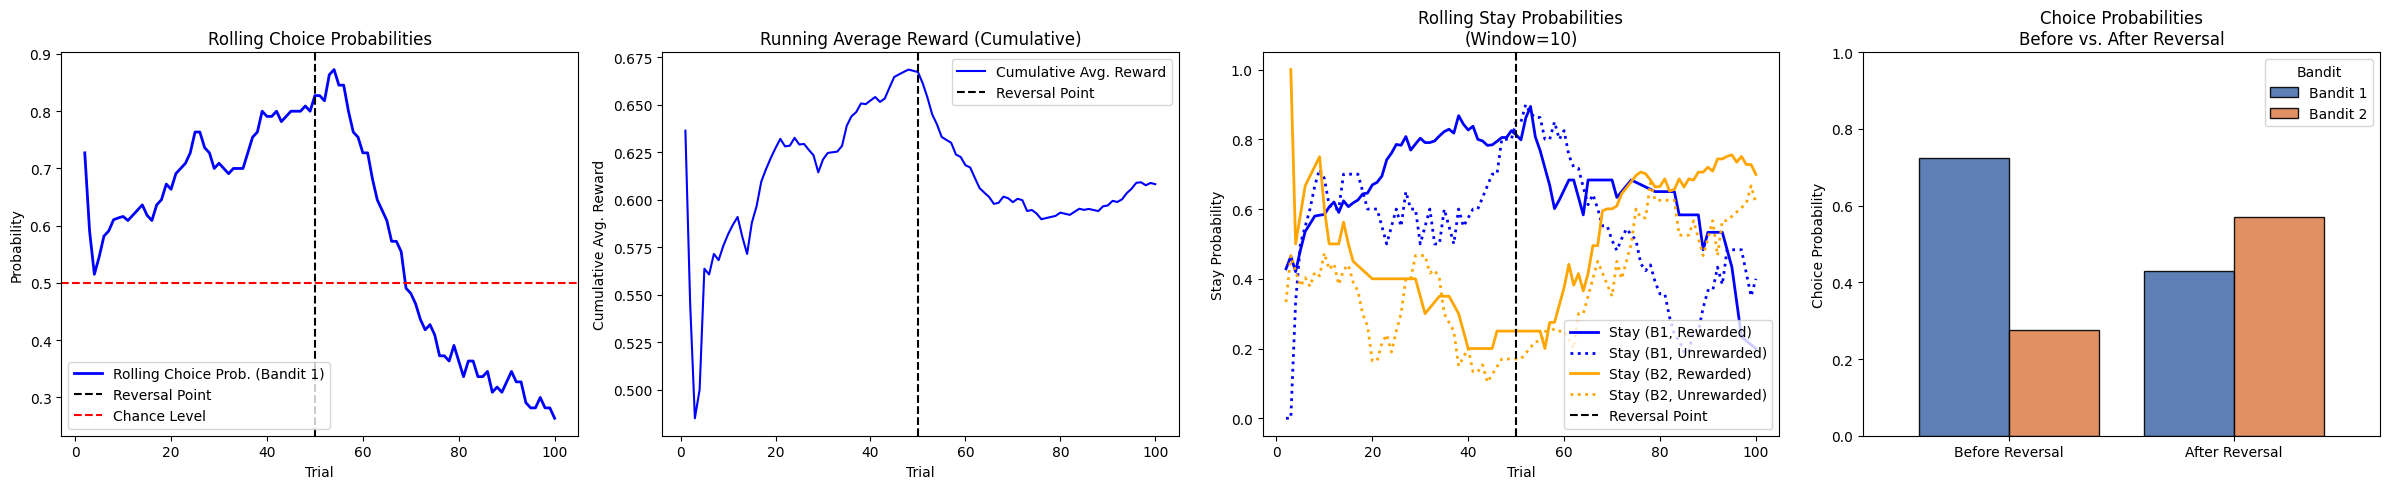

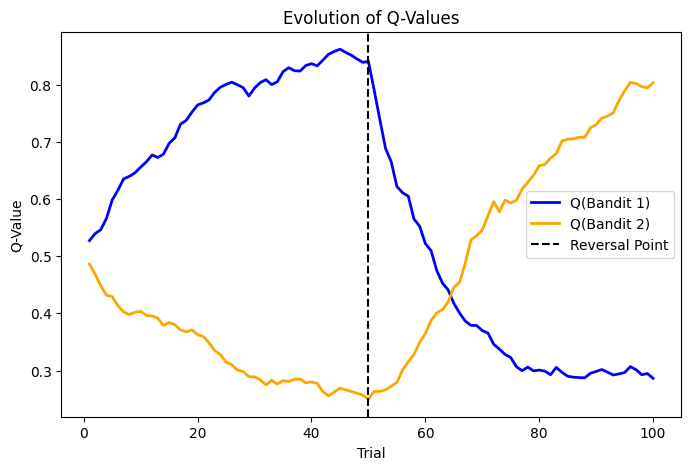

In [ ]:
#Plotting the simulated behavior of the RWM for inspection.

# First, plot the standard behavioral metrics
plot_behaviour(simulated_df_RWM)

# Then we compute mean Q-values per trial across participants
q_values = simulated_df_RWM.groupby("trial")[["Q_Value_Bandit1", "Q_Value_Bandit2"]].mean()

# Plot Q-values over trials
plt.figure(figsize=(8, 5))
plt.plot(q_values.index, q_values["Q_Value_Bandit1"], label="Q(Bandit 1)", color="blue", lw=2)
plt.plot(q_values.index, q_values["Q_Value_Bandit2"], label="Q(Bandit 2)", color="orange", lw=2)
plt.axvline(50, color="black", linestyle="--", label="Reversal Point")  # Assuming reversal at trial 50
plt.xlabel("Trial")
plt.ylabel("Q-Value")
plt.title("Evolution of Q-Values")
plt.legend()
plt.show()


 **Explanations of Plots:**


**Evolution of Q-values over Trials (Plot 1):**

This plot shows how the estimated values (Q-values) for each bandit change over time. The Q-value for each bandit is updated based on the rewards received, and averaging these values over all participants gives an idea of how the agent learns which option is more rewarding. As learning progresses, you’d expect the Q-value of the optimal bandit to increase relative to the suboptimal one.

The evolution of Q-values is calculated by averaging the estimated values (Q-values) for each bandit over all participants on each trial. This gives you the trajectory of how the estimated reward value for each option changes over time as the agent learns from feedback. Essentially, it shows how the model’s expectations for each bandit develop across the course of the experiment.

**Trial-wise Choice Probabilities (Plot 2):**

This plot displays the probability of choosing Bandit 1 on each trial (assuming Bandit 1 is coded as 0). It represents the learning curve in terms of decision-making – as the agent learns, the probability of selecting the better option should change (either increasing or decreasing, depending on how the choices are coded). Essentially, it shows the shifting balance in the agent’s choices over the course of the experiment.

The trial-wise choice probability is calculated by taking the average of the choices across all participants for each individual trial. For instance, if you code Bandit 1 as 0 and Bandit 2 as 1, then the average for each trial tells you the proportion of participants choosing Bandit 1 on that trial. This provides the overall choice probability for each trial, showing how frequently each option is selected at that specific time.

**Rolling Stay Probabilities over Trials (Plot 3):**

Here we plot the smoothed (rolling average) probabilities that the agent repeats its previous choice, separated by conditions (rewarded vs. unrewarded) for each bandit. Stay probabilities give insight into the exploitation side of the exploration–exploitation tradeoff. For instance, a high stay probability following a reward suggests that the agent is exploiting that option. This plot helps visualize how the tendency to stick with the same choice evolves as the agent learns from past outcomes.

The rolling stay probabilities are calculated by first computing, for each trial, the proportion of participants who repeated their previous choice (i.e., stayed with the same option) based on whether the previous outcome was rewarded or unrewarded. Then, these per‐trial stay probabilities are smoothed using a rolling (moving) average with a specified window (e.g., 10 trials). This gives you a smoothed estimate of the probability that participants repeat their previous choice over all the trials up to each point.

: the probability of repeating an
action, pðstayÞ(should I change my behavior in response to feedback?), and the probability of
choosing the correct option, pðcorrectÞ(have I learned?).

**Running Average Reward over Trials (Plot 4):**

This plot shows the running average (cumulative average) reward over trials. For each trial, it averages the total reward accumulated so far by the number of trials up to that point. This smoothing helps reveal the trend in performance: as the agent learns, the running average reward should increase and then plateau when optimal performance is reached. It provides an overall measure of how effectively the agent is learning from the environment.

The running average reward is calculated by taking the cumulative sum of the average rewards from trial 1 up to the current trial, then dividing by the number of trials so far. This gives you the average reward per trial accumulated over all the trials up to that point (Max 1).

**Grouped Bar Plot of Choice Probabilities Before vs. After Reversal (Plot 5):**

This bar plot compares the overall choice probabilities for each bandit during two distinct periods: before the reversal (trials ≤ 50) and after the reversal (trials > 50). By grouping the data into these two phases, you can see how the agent’s preference shifts when the environment changes. For example, if the optimal bandit switches after reversal, you’d expect to see a corresponding change in the choice probabilities for each bandit between the “Before” and “After” groups.

The grouped bar plot is calculated by first splitting the trials into two periods—"Before" the reversal and "After" the reversal. For each period, you average the choice data across all trials to get the overall proportion of choices for each bandit. This gives you the overall choice probability for each bandit in each period. These averages are then plotted as bars, with one bar representing Bandit 1 and one representing Bandit 2 for the "Before" group, and similarly for the "After" group.

We wanted to look at the Q Value Evolution (How the estimated values for each option change over trials), Learning Curves (How performance improves over time), Reversal adaptaption (How the model adapts when the reward contingencies change (e.g., at a reversal point))

## **2.2. BRM Simulation**

### **Simulate data from both model for a single set of parameters. The simulation should mimic the experiment you are trying to model.**

This code simulates the behavior of multiple participants using the BRM model. It tracks how participants learn over multiple trials and updates their beliefs about two bandits based on rewards, making decisions using a softmax decision rule.

**Simulation Parameters:**
- **n_participants (11)**: number of participants in the simulation.
- **n_trials (100)**: number of trials each participant completes.
- **prior_alpha (1)**, **prior_beta (1)**: beta distribution parameters for initial beliefs. A uniform Beta prior reflects an unbiased starting point for learning (gershman2015).
- **inv_temp (3)**: inverse temperature for softmax decision rule (controls randomness in decisions). A moderate value balances exploration and exploitation (daw2011).
- **hazard_rate (0.15)**: rate at which beliefs decay over time (forgetting). This value reflects gradual adaptation and is supported by prior work on belief updating in volatile environments (nassar2010).

**Simulation Loop:**  
For each participant:
1. **Reset agent beliefs** to the initial prior values.
2. **Loop through trials** (100 trials each):
   - Compute the expected values $\mu_0$ and $\mu_1$ for the two bandits based on the current **Beta distribution**.
   - Calculate **choice probabilities** using softmax function:  
     $$ P(a) = \frac{e^{\beta Q(a)}}{\sum_{b} e^{\beta Q(b)}} $$  
     where $Q(a)$ is the expected value for bandit $a$, and $\beta$ is the inverse temperature.
   - **Choose bandit** based on the computed probabilities.
   - **Assign rewards**: The reward probability for each bandit changes at trial 50 (reversal point).
     - **First 50 trials**: Bandit 1 has an 80% reward, and Bandit 2 has 20%.
     - **After trial 50**: The reward probabilities are reversed.
   - **Update beliefs** using reward feedback.

In [ ]:
import numpy as np
import pandas as pd

# simulation parameters
n_participants = 11
n_trials = 100 # number of trials
prior_alpha = 1
prior_beta = 1
inv_temp = 3 # softmax inverse temperature
hazard_rate = 0.15 # belief decay rate

# storage for all participants
all_choices = []
all_rewards = []
all_mu_histories = []
all_alpha_histories = []
all_beta_histories = []
participant_ids = []

# simulate behavior using Bayesian RL model
for p in range(n_participants):
  agent = BayesianRLModel(prior_alpha=prior_alpha, prior_beta=prior_beta, inv_temp=inv_temp, hazard_rate=hazard_rate)
  agent.reset() # ensure beliefs reset for each participant

  choices = []
  rewards = []
  mu_history = [] # track expected values
  alpha_history = []
  beta_history = []

  for t in range(n_trials):
    # compute expected values for both bandits
    (mu0, mu1), _ = agent.compute_values()

    # compute choice probabilities
    probs = agent.compute_choice_probabilities((mu0, mu1))

    # choose bandit based on probabilities
    choice = np.random.choice([0, 1], p=probs)

    # determine reward probability based on trial number (reverse at trial 50)
    if t < 50:
        reward_prob = 0.8 if choice == 0 else 0.2  # bandit 1: 80%, bandit 2: 20%
    else:
        reward_prob = 0.8 if choice == 1 else 0.2  # reversal point: bandit 1: 20%, bandit 2: 80%

    # assign reward & convert boolean to int
    reward = int(np.random.rand() < reward_prob)

    # store belief parameters (before updating)
    alpha_history.append([agent.alpha[0], agent.alpha[1]])
    beta_history.append([agent.beta[0], agent.beta[1]])

    # update beliefs based on choice and reward
    agent.update_beliefs(choice, reward)

    # store trial data
    choices.append(choice)
    rewards.append(reward)
    mu_history.append([mu0, mu1])

  # store participant data
  all_choices.append(choices)
  all_rewards.append(rewards)
  all_mu_histories.append(mu_history)
  all_alpha_histories.append(alpha_history)
  all_beta_histories.append(beta_history)
  participant_ids.extend([p] * n_trials)

# convert lists to numpy arrays
all_choices = np.array(all_choices).flatten()
all_rewards = np.array(all_rewards).flatten()
all_mu_histories = np.array(all_mu_histories)
all_alpha_histories = np.array(all_alpha_histories)
all_beta_histories = np.array(all_beta_histories)

# create df for Bayesian RL Model simulation
simulated_df_Bayes = pd.DataFrame({
  "participant_id": participant_ids,
  "trial": np.concatenate([np.arange(1, n_trials + 1) for _ in range(n_participants)]),
  "choice": all_choices,
  "reward": all_rewards,
  "expected_value_0": all_mu_histories[:, :, 0].flatten(),
  "expected_value_1": all_mu_histories[:, :, 1].flatten(),
  "alpha_0": all_alpha_histories[:, :, 0].flatten(),
  "alpha_1": all_alpha_histories[:, :, 1].flatten(),
  "beta_0": all_beta_histories[:, :, 0].flatten(),
  "beta_1": all_beta_histories[:, :, 1].flatten(),
})

# print first 10 trials of participant 1
print("Simulated choices (first 10 trials of participant 1):",
  simulated_df_Bayes[simulated_df_Bayes["participant_id"] == 0]["choice"][:10].values)

print("Simulated rewards (first 10 trials of participant 1):",
  simulated_df_Bayes[simulated_df_Bayes["participant_id"] == 0]["reward"][:10].values)

print(simulated_df_Bayes.head(10))

Simulated choices (first 10 trials of participant 1): [0 0 1 0 0 0 0 0 1 0]
Simulated rewards (first 10 trials of participant 1): [0 1 0 1 1 0 1 0 0 1]
   participant_id  trial  choice  reward  expected_value_0  expected_value_1  \
0               0      1       0       0          0.500000          0.500000   
1               0      2       0       1          0.350877          0.500000   
2               0      3       1       0          0.517845          0.500000   
3               0      4       0       1          0.516240          0.350877   
4               0      5       0       1          0.618175          0.367309   
5               0      6       0       0          0.681878          0.382537   
6               0      7       0       1          0.555235          0.396510   
7               0      8       0       0          0.622097          0.409215   
8               0      9       1       0          0.523686          0.420672   
9               0     10       0       1        

### **Plot the simulated behavior of both models. The model plots should depict key features of the behavioral data, convincing that the models are suitable to capture the data.**

This code first plots standard behavioral metrics using `plot_behaviour`, which was also used before. It then calculates the mean expected values for each bandit across trials and participants. The evolution of expected values is plotted to show how beliefs about each bandit's value change over time. The reversal point (trial 50) is marked with a dashed line (switch in reward probabilities).

The "Evolution of Expected Values Over Trials" plot visualises how the agent's beliefs (expected values) for each bandit evolve over time across trials. The expected value is computed as the mean of the Beta distribution for each bandit, which represents the agent’s estimate of the reward probability. Initially, as the agent interacts with the environment, the expected values of both bandits shift based on the rewards received.

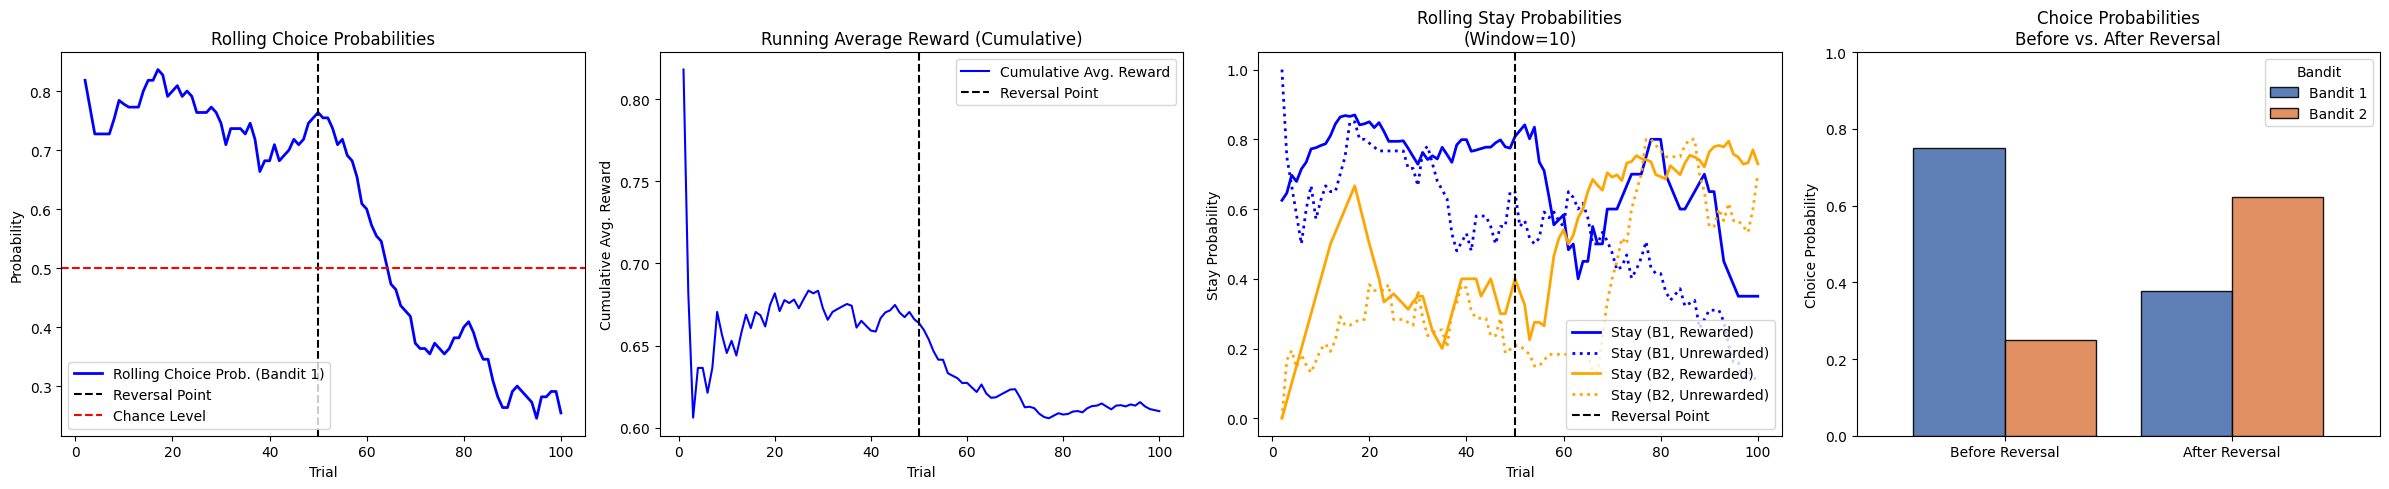

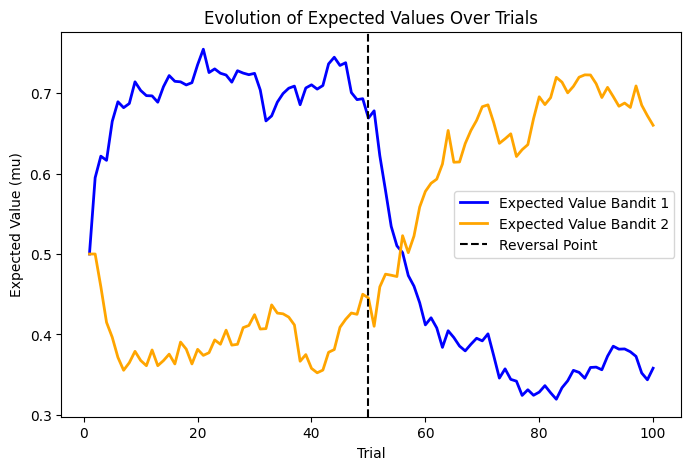

In [ ]:
# first, plot the standard behavioral metrics
plot_behaviour(simulated_df_Bayes)

# compute mean expected values over trials (averaged across participants)
mean_expected_values = simulated_df_Bayes.groupby("trial")[["expected_value_0", "expected_value_1"]].mean()

# plot evolution of expected values (beliefs) over trials
plt.figure(figsize=(8, 5))
plt.plot(mean_expected_values.index, mean_expected_values["expected_value_0"], label="Expected Value Bandit 1", color="blue", lw=2)
plt.plot(mean_expected_values.index, mean_expected_values["expected_value_1"], label="Expected Value Bandit 2", color="orange", lw=2)
plt.axvline(50, color="black", linestyle="--", label="Reversal Point") # mark reversal point
plt.xlabel("Trial")
plt.ylabel("Expected Value (mu)")
plt.title("Evolution of Expected Values Over Trials")
plt.legend()
plt.show()


# **3. Parameter Fitting**

*   Steps:

*   Set up a suitable parameter search space

*   Implement a procedure to evaluate the fit of a model based on data 

*   Implement a procedure for searching the parameter space. 

## **3.1. RWM Fitting**

### **Set up a suitable parameter search space**




In this code block, we **define the parameter space for fitting the model to human data**. We set **reasonable ranges** for the learning rate (**α**) and inverse temperature (**β**) based on prior studies in reinforcement learning.  

- **α (learning rate)**: Ranges from **0.05 to 0.8**, allowing flexibility to capture **both slow and fast learners**. A lower α suggests **gradual updating**, while a higher α allows for **rapid adaptation**.  
- **β (inverse temperature)**: Ranges from **0.1 to 10**, covering **both exploratory and exploitative behaviors**. Lower values encourage **random exploration**, while higher values promote **more deterministic, reward-driven choices**.  

We use **10 steps for α** and **30 steps for β** to create a **fine-grained search space** for model fitting. These values ensure that our parameter grid can accurately capture **individual differences in learning and decision-making**.

In [ ]:
import numpy as np

# Define parameter search space for fitting human data
alpha_min = 0.05
alpha_max = 0.8
alpha_resolution = 21  # Adjust if needed for finer search
beta_min = 0.1
beta_max = 10
beta_resolution = 21  # Fine search resolution

param_human_space = {
    'alpha': np.linspace(alpha_min, alpha_max, alpha_resolution),
    'beta': np.linspace(beta_min, beta_max, beta_resolution)
}



### **Implement a procedure to evaluate the fit of a model based on data (2 points)**  



In this code block, we **compute the log-likelihood** of observed participant choices given a **Rescorla-Wagner agent**. The log-likelihood measures **how well the model explains human behavior**, with higher values indicating a better fit.  

**Key Steps:**  
- **Initialize log-likelihood (`ll_sum`)** and reset the agent’s **Q-values**.  
- **Iterate through each trial**, retrieving the participant’s choice and received reward.  
- **Extract action probabilities** from the agent and compute the likelihood of the chosen action.  
- **Update Q-values** based on the observed reward to simulate learning.  
- **Accumulate the log-likelihood** over all trials, returning the final value as a measure of model fit.  

This function is **essential for model fitting**, allowing us to compare different parameter values and determine **which settings best capture human decision-making**.

In [ ]:
import numpy as np

def log_likelihood(agent, data):
    """
    Computes the log-likelihood of observed choices given a Rescorla-Wagner agent.

    :param agent: An instance of a Rescorla-Wagner agent.
    :param data: A pandas DataFrame containing observed behavioral data.
                 Expected columns: ['trial', 'choice', 'reward']
    :return: The summed log-likelihood.
    """
    ll_sum = 0  # Initialize log-likelihood sum

    # Reset Q-values (ensure agent starts fresh each time)
    agent.Q_values = np.array([0.5, 0.5])

    for _, trial_data in data.iterrows():
        chosen_action = trial_data['choice']  # The action taken
        received_reward = trial_data['reward']  # The observed reward

        # Get action probabilities from the agent
        action_probs = agent.get_action_probabilities()
        chosen_action_prob = action_probs[chosen_action]

        # Update Q-values using the agent's method
        agent.update_q_values(chosen_action, received_reward)

        # Accumulate log-likelihood
        ll_sum += np.log(chosen_action_prob)

    return ll_sum



### **Implement a procedure for searching the parameter space**  



In this code block, we **perform a grid search** over the predefined **α (learning rate) and β (inverse temperature)** values to find the **best-fitting parameters** for the Rescorla-Wagner model based on **log-likelihood**.  

**Key Steps:**  
- **Initialize search variables**, including a log-likelihood matrix and a tracking mechanism for the best parameters.  
- **Iterate over all combinations of α and β**, fitting a **Rescorla-Wagner agent** to the data for each pair.  
- **Compute the log-likelihood** of observed choices given the agent’s decisions.  
- **Store log-likelihood values** in a matrix and update the best-fitting parameters if a higher log-likelihood is found.  
- **Return the best α and β**, along with the full log-likelihood matrix for further analysis.  

This procedure **optimizes the model fit to human data**, ensuring that we select **parameters that best explain participants' decision-making behavior**.

In [ ]:
import numpy as np
from tqdm import tqdm  # For progress bar

def grid_search(agent_class, data, param_space):
    """
    Performs a grid search over alpha and beta to find the best-fitting parameters
    based on log-likelihood.

    :param agent_class: The Rescorla-Wagner agent class.
    :param data: DataFrame with observed choices and rewards.
    :param param_space: Dictionary with search values for 'alpha' and 'beta'.
    :return: Best parameters (alpha, beta) and log-likelihood matrix.
    """
    best_alpha = None
    best_beta = None
    best_LL = -np.inf  # Start with the lowest possible LL

    # Initialize log-likelihood matrix
    LL_matrix = np.zeros((len(param_space['alpha']), len(param_space['beta'])))

    # Loop over all combinations of alpha and beta
    for i, alpha in enumerate(tqdm(param_space['alpha'], desc="Grid Search (Alpha)")):
        for j, beta in enumerate(param_space['beta']):

            # Initialize a fresh agent with current parameters
            agent = agent_class(alpha=alpha, beta=beta)

            # Compute log-likelihood
            LL = log_likelihood(agent, data)

            # Store LL in the matrix
            LL_matrix[i, j] = LL  # (i: alpha, j: beta)

            # Update best parameters if a better LL is found
            if LL > best_LL:
                best_LL = LL
                best_alpha = alpha
                best_beta = beta

    return {"alpha": best_alpha, "beta": best_beta}, LL_matrix



## **3.2. BRM Fitting**

### **Set up a suitable parameter search space**


In this code block, we set ranges for the **inverse temperature** and **hazard rate** based on their roles in controlling decision-making dynamics.

- **Inverse Temperature (inv_temp)**: Ranges from **0.1 to 10**, controlling the randomness of choices. A lower value encourages exploration by making the agent’s choices more random, while a higher value makes the agent more deterministic, favoring the option with the highest expected reward.
- **Hazard Rate (hazard_rate)**: Ranges from **0.01 to 0.5**, controlling how quickly the agent's beliefs drift toward its prior knowledge. A higher hazard rate means the agent updates its beliefs faster, while a lower rate means it relies more on the initial prior beliefs.

We found that no prior biases (alpha and beta at 0) produce the best fit to real human data. Moreover, having no biases allows the model to slowly adjust the prior belief of bandits over time, letting the agent learn as it continues chosing bandits.

An alternative is to use **16 (alpha) and 4 (beta)** for our Beta distribution prior values, based on (Steyvers et al. 2009) and a reasonable assumption of human cognition and predefined biases.

In [ ]:
from tqdm import tqdm

# --- define parameter search space ---
# inverse temperature: controls choice randomness
inv_temp_min = 0.1
inv_temp_max = 10.0
inv_temp_resolution = 21 # adjust for finer search

# hazard rate: controls how quickly beliefs drift toward the prior
hazard_rate_min = 0.01
hazard_rate_max = 0.5
hazard_rate_resolution = 21

# fixed prior belief parameters on the bandits
prior_alpha = 1
prior_beta = 1

# create a grid for the two free parameters
param_human_space_bayes = {
  'inv_temp': np.linspace(inv_temp_min, inv_temp_max, inv_temp_resolution),
  'hazard_rate': np.linspace(hazard_rate_min, hazard_rate_max, hazard_rate_resolution)
}

### **Implement a procedure to evaluate the fit of a model based on data**  

Here we define the **log-likelihood function** to evaluate how well a BRM agent explains observed data.

The `log_likelihood_bayes` function calculates the log-likelihood of the observed choices made by the agent, based on its beliefs about the environment. It loops through the trials in the provided data, computes the expected values (μ) for each bandit, and determines the action probabilities using the softmax function. For each trial, the function adds the log of the probability of the chosen action to the total log-likelihood. The agent's beliefs are updated with each observed choice and reward. Finally, the function returns the summed log-likelihood, which reflects how well the agent's model fits the observed behavior.



In [ ]:
import numpy as np

def log_likelihood_bayes(agent, data):
  """
  Computes the log-likelihood of observed choices given a Bayesian RL agent.

  This follows the same structure as the Rescorla-Wagner log-likelihood function.

  :param agent: An instance of BayesianRLModel.
  :param data:  A pandas DataFrame containing observed behavioral data.
                Expected columns: ['trial', 'choice', 'reward']
  :return:      The summed log-likelihood.
  """
  ll_sum = 0 # initialize log-likelihood sum

  # reset agent's beliefs before processing data
  agent.reset()

  for _, trial_data in data.iterrows():
    chosen_action = int(trial_data['choice']) # observed
    received_reward = int(trial_data['reward'])

    # compute expected values (mu) for both bandits
    (mu0, mu1), _ = agent.compute_values()

    # compute action probabilities using softmax
    action_probs = agent.compute_choice_probabilities((mu0, mu1))
    chosen_action_prob = action_probs[chosen_action]

    # update beliefs using the observed action and reward
    agent.update_beliefs(chosen_action, received_reward)

    # accumulate log-likelihood and add value to aavoid log errors
    ll_sum += np.log(chosen_action_prob + 1e-8)

  return ll_sum

### **Implement a procedure for searching the parameter space**  

This function performs a grid search to find the best-fitting BRM model based on the log-likelihood of observed behavioral data. It searches over different values of two parameters: inverse temperature (`inv_temp`) and hazard rate (`hazard_rate`).

**Parameters:**
- **agent_class**: The `BayesianRLModel` class used for the simulation.
- **data**: A pandas DataFrame containing observed data (e.g., choices, rewards).
- **param_space**: A dictionary containing possible values for `inv_temp` and `hazard_rate`.
  - Example:  
    `param_space = {'inv_temp': [1, 2, 3], 'hazard_rate': [0.1, 0.2, 0.3]}`
- **fixed_params**: A dictionary of fixed parameters (like `prior_alpha` and `prior_beta`) that do not change during the search.

**Process:**
- The function iterates over all combinations of `inv_temp` and `hazard_rate` from the `param_space`.
- For each combination:
  1. A new instance of the **BayesianRLModel** is created with the current values of `inv_temp` and `hazard_rate`, along with the fixed priors.
  2. The **log-likelihood** is computed using the `log_likelihood_bayes()` function.
  3. The log-likelihood value is stored in a matrix for later comparison.
  4. The best parameters (those yielding the highest log-likelihood) are tracked.

**Output:**
- The function returns:
  - **best_params**: The optimal values of `inv_temp` and `hazard_rate`.
  - **LL_matrix**: A matrix with log-likelihood values for each combination of parameters.

In [ ]:
from tqdm import tqdm
import numpy as np

def grid_search_bayes(agent_class, data, param_space, fixed_params):
  """
  Performs a grid search over inv_temp and hazard_rate parameters
  to find the best-fitting Bayesian RL model based on log-likelihood.

  :param agent_class: BayesianRLModel class.
  :param data: pandas DataFrame with observed behavioral data.
  :param param_space: Dictionary with keys 'inv_temp' and 'hazard_rate' containing lists of search values.
  :param fixed_params: Fixed parameters (priors) for the model.
  :return: Dictionary with best parameters {'inv_temp', 'hazard_rate'} and the log-likelihood matrix.
  """

  print("DEBUG: Entered grid_search_bayes()")
  print("DEBUG: Received param_space keys:", param_space.keys())

  # ensure the parameter space is correct before looping
  assert "inv_temp" in param_space, "ERROR: 'inv_temp' missing in param_space!"
  assert "hazard_rate" in param_space, "ERROR: 'hazard_rate' missing in param_space!"

  best_params = {"inv_temp": None, "hazard_rate": None}
  best_LL = -np.inf # initialize with a very low value

  # Create a matrix to store log-likelihood values
  LL_matrix = np.zeros((len(param_space['inv_temp']), len(param_space['hazard_rate'])))

  # Loop over each combination of inv_temp and hazard_rate
  for i, inv_temp in enumerate(tqdm(param_space['inv_temp'], desc="Grid Search (inv_temp)")):
    for j, hazard_rate in enumerate(tqdm(param_space['hazard_rate'], desc="Grid Search (hazard_rate)", leave=False)):
      # Create a fresh Bayesian RL model instance
      agent = agent_class(prior_alpha=fixed_params['prior_alpha'],
                          prior_beta=fixed_params['prior_beta'],
                          inv_temp=inv_temp,
                          hazard_rate=hazard_rate)

      # Compute log-likelihood
      LL = log_likelihood_bayes(agent, data)
      LL_matrix[i, j] = LL  # Store result in matrix

      # Update best parameters if current log-likelihood is higher
      if LL > best_LL:
        best_LL = LL
        best_params["inv_temp"] = inv_temp
        best_params["hazard_rate"] = hazard_rate

  print("DEBUG: Best parameters found:", best_params)
  return best_params, LL_matrix

# **4. Parameter Recovery**

## **4.1.  RWM Parameter Recovery (Simulated Data RWM)**

### **Set up a suitable space of parameters relevant for parameter recovery**  



In this code block, we **define the parameter space for parameter recovery**, ensuring that the recovered values align with **realistic human learning behavior** in the Rescorla-Wagner model.  

**Why We Chose These Ranges:**  
- **α (learning rate: 0.01–0.8)** → Covers **slow to fast learners**, allowing for both **gradual** and **rapid** updating of Q-values. Values above 0.8 would lead to excessive volatility, while values below 0.01 would make learning too slow.  
- **β (inverse temperature: 0.01–8)** → Ensures **sufficient exploration-exploitation balance**. Values near 0 lead to almost random choices, while very high values (above 8) make choices too deterministic.  

We use **21 interpolation steps** to create a **fine-grained grid search**, ensuring thorough exploration of parameter values. Additionally, **random search distributions** are defined using uniform sampling, allowing **stochastic optimization techniques** for efficient parameter recovery.

In [ ]:


from scipy.stats import uniform
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Define parameter search space for parameter recovery
ALPHA_RANGE = (0.01, 0.8)  # Learning rate range (reasonable for RW models)
BETA_RANGE = (0.01, 8)  # Inverse temperature range (avoiding negatives)

INTERPOLATION_STEPS = 21  # Number of steps for interpolation (granularity)

# Define parameter grid for exhaustive search (grid search)
param_recovery_space = {
    'alpha': np.linspace(*ALPHA_RANGE, INTERPOLATION_STEPS),
    'beta': np.linspace(*BETA_RANGE, INTERPOLATION_STEPS)
}

# Define parameter distributions for random search (stochastic optimization)
param_recovery_distributions = {
    'alpha': uniform(ALPHA_RANGE[0], ALPHA_RANGE[1] - ALPHA_RANGE[0]),
    'beta': uniform(BETA_RANGE[0], BETA_RANGE[1] - BETA_RANGE[0])
}


### **Using the functions above to generate behavior from a models, for a given set of (randomly sampled) parameters, and then fit the model to its generated data.**




In this code block, we **test the ability of our model to recover parameters** by simulating behavior from a known set of **randomly sampled parameters**, then attempting to **recover them** using model fitting.  

**Key Steps:**  

1. **Parameter Sampling & Simulation**  
   - **Randomly sample α and β** from the predefined parameter space.  
   - Use these parameters to **simulate behavior** for multiple participants using the **Rescorla-Wagner model**.  

2. **Data Collection & Formatting**  
   - Store **choices, rewards, and participant IDs** into a structured **DataFrame**, mimicking real experimental data.  

3. **Model Fitting & Parameter Recovery**  
   - Fit the model to the simulated data using **grid search** to find the best **α and β**.  
   - **Compare the fitted parameters to the true sampled parameters** to assess recovery accuracy.  

4. **Quantitative Evaluation**  
   - Store **log-likelihood values** as a measure of model fit quality.  
   - Analyze how well the recovered parameters match the true ones.  

This procedure ensures that the **Rescorla-Wagner model fitting is reliable**, validating that it can accurately estimate **cognitive parameters** from behavioral data.

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm

def param_recovery(agent_class, param_space, num_participants=11, num_trials=100, num_runs=20):
    """
    Performs parameter recovery: simulates behavior using the same parameters across participants,
    then fits the model to recover those parameters.

    :param agent_class: The Rescorla-Wagner agent class.
    :param param_space: Dictionary specifying the parameter ranges.
    :param num_participants: Number of participants per run.
    :param num_trials: Number of trials per participant.
    :param num_runs: Number of simulated datasets to generate and fit.
    :return: Fitted parameters, true parameters, and log-likelihood values.
    """
    # Step 1: Initialize storage for results
    true_params = {param: [] for param in param_space.keys()}  # True α, β per run
    fitted_params = {param: [] for param in param_space.keys()}  # Recovered α, β per run
    best_LLs = []  # Log-likelihood values per run

    # Step 2: Loop through multiple simulation runs
    for run in tqdm(range(num_runs), desc='Fitting Runs', total=num_runs, leave=True):
        # Step 3: Sample one set of true parameters for this run
        sampled_params = {param: np.random.uniform(np.min(param_space[param]), np.max(param_space[param])) for param in param_space.keys()}

        # Store true parameters
        for param in param_space.keys():
            true_params[param].append(sampled_params[param])

        # Step 4: Simulate behavior for all 11 participants using the same parameters
        all_choices = []
        all_rewards = []
        participant_ids = []

        for p in range(num_participants):
            agent = agent_class(alpha=sampled_params['alpha'], beta=sampled_params['beta'])
            choices, rewards, _ = agent.simulate(n_trials=num_trials)

            # Store participant data
            all_choices.extend(choices)
            all_rewards.extend(rewards)
            participant_ids.extend([p] * num_trials)  # Assign participant ID

        # Convert simulated data into a DataFrame
        sim_data = pd.DataFrame({
            "participant": participant_ids,
            "trial": np.tile(np.arange(num_trials), num_participants),
            "choice": all_choices,
            "reward": all_rewards
        })

        # Step 5: Fit the model to recover parameters for this run
        best_params, best_LL = grid_search(agent_class, sim_data, param_space)

        # Store recovered parameters
        for param in param_space.keys():
            fitted_params[param].append(best_params[param])

        # Store log-likelihood
        best_LLs.append(best_LL)

    return fitted_params, true_params, best_LLs


In this code block, we **execute the parameter recovery process** by running the **Rescorla-Wagner model simulation and fitting procedure** over multiple runs.  

**Steps:**  
- **Simulates 11 participants per run**, each completing **100 trials**.  
- **Randomly samples α and β** for each run, simulating behavior using the **Rescorla-Wagner agent**.  
- **Runs the fitting procedure 20 times**, ensuring **robustness in parameter recovery**.  
- Stores the **fitted parameters, true parameters, and best log-likelihoods** for later analysis.  

This **validates model reliability** by testing how well the fitted parameters match the true ones across **multiple independent runs**.


In [ ]:
# Run the parameter recovery process with 11 participants per run
fitted_params, true_params, best_LLs = param_recovery(
    RescorlaWagnerAgent,  # The agent class
    param_recovery_space,  # Parameter search space
    num_participants=11,  # Simulating 11 participants per run
    num_trials=100,  # Each participant completes 100 trials
    num_runs=20  # Running 20 separate simulations
)


Fitting Runs: 100%|██████████| 20/20 [09:09<00:00, 27.46s/it]


### **Plotting the parameter recovery results for both models**  



In this code block, we **evaluate the accuracy of parameter recovery** by plotting **true vs. fitted parameters** and analyzing their correlation.  

**Key Steps:**  
1. **Scatter Plots for True vs. Fitted Parameters**  
   - Compares recovered parameters to the actual values used in simulation.  
   - Includes an **identity line** (dashed) to assess perfect recovery.  

2. **Pearson Correlation Analysis**  
   - Computes the **correlation coefficient (r)** and **p-value** to measure the **goodness of recovery**.  

3. **Parameter Correlation Plot**  
   - Checks the relationship between **α (learning rate) and β (inverse temperature)** in the recovered values.  
   - Helps detect potential **parameter dependencies or trade-offs**.  

These visualizations **validate model performance**, ensuring that the fitting process successfully recovers meaningful cognitive parameters.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

def plot_param_recovery(true_params: dict, fitted_params: dict, title='', max_plots_per_row: int=3, save=False, filename='param_recovery.png'):
    """
    Plots true vs. fitted parameters to assess parameter recovery.

    :param true_params: Dictionary of true parameters used for simulation.
    :param fitted_params: Dictionary of recovered parameters after fitting.
    :param title: Title for the plot.
    :param max_plots_per_row: Number of plots per row.
    :param save: Whether to save the plot.
    :param filename: Filename if saving.
    """
    n_params = len(true_params)

    rows = (n_params - 1) // max_plots_per_row + 1  # Ensure at least one row
    cols = min(n_params, max_plots_per_row)

    fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(6 * cols, 6 * rows))
    fig.suptitle(title)
    axes = axes.flatten() if n_params > 1 else [axes]  # Ensure iterable axes

    for i, param in enumerate(true_params.keys()):
        ax = axes[i]
        true_values = np.array(true_params[param])
        fitted_values = np.array(fitted_params[param])

        sns.scatterplot(x=true_values, y=fitted_values, ax=ax)
        ax.set_title(f'{param}')
        ax.set_xlabel('True')
        ax.set_ylabel('Fitted')

        # Plot identity line (perfect recovery)
        min_val, max_val = min(true_values.min(), fitted_values.min()), max(true_values.max(), fitted_values.max())
        ax.plot([min_val, max_val], [min_val, max_val], ls="--", c=".3")

        # Compute Pearson correlation
        corr_coef, p_value = pearsonr(true_values, fitted_values)
        print(f'Pearson correlation for {param}: {corr_coef:.3f}, p-value: {p_value:.3f}')

    fig.tight_layout()
    if save:
        plt.savefig(filename)
    plt.show()


def plot_param_correlation(fitted_params: dict, title='', save=False, filename='recovered_param_correlation.png'):
    """
    Plots the correlation between the two recovered parameters (e.g., alpha and beta).

    :param fitted_params: Dictionary of recovered parameters.
    :param title: Title for the plot.
    :param save: Whether to save the plot.
    :param filename: Filename if saving.
    """
    param_names = list(fitted_params.keys())

    if len(param_names) < 2:
        print("Error: Need at least two parameters to compute correlation.")
        return

    # Compute Pearson correlation between fitted parameters
    corr_coef, p_value = pearsonr(fitted_params[param_names[0]], fitted_params[param_names[1]])
    print(f'Correlation between {param_names[0]} and {param_names[1]}: {corr_coef:.3f}, p-value: {p_value:.3f}')

    # Create scatter plot
    fig, ax = plt.subplots(figsize=(6, 6))
    fig.suptitle(f'{title} Correlation: {corr_coef:.3f}')

    sns.scatterplot(x=fitted_params[param_names[0]], y=fitted_params[param_names[1]], ax=ax)
    ax.set_xlabel(param_names[0])
    ax.set_ylabel(param_names[1])
    ax.set_title(f'{title}')

    if save:
        plt.savefig(filename)
    plt.show()


**Parameter Recovery Evaluation**  

In this code block, we **visualize and assess the accuracy of the recovered parameters**:  

1. **`plot_param_recovery(true_params, fitted_params)`**  
   - Generates scatter plots for **true vs. fitted parameters** to check how well the model recovers α and β.  
   - A strong **diagonal alignment** indicates accurate recovery.  

2. **`plot_param_correlation(fitted_params)`**  
   - Plots the correlation between **fitted α and β** to examine potential dependencies.  
   - A **low correlation** suggests that the parameters are independently estimated, while a **high correlation** may indicate an overlap in their influence on behavior.  

These plots provide a quantitative and visual check on the reliability of our model-fitting process, indicating whether the recovered parameters align well with the true values and whether any dependencies exist between them.

Pearson correlation for alpha: 0.943, p-value: 0.000
Pearson correlation for beta: 0.739, p-value: 0.000


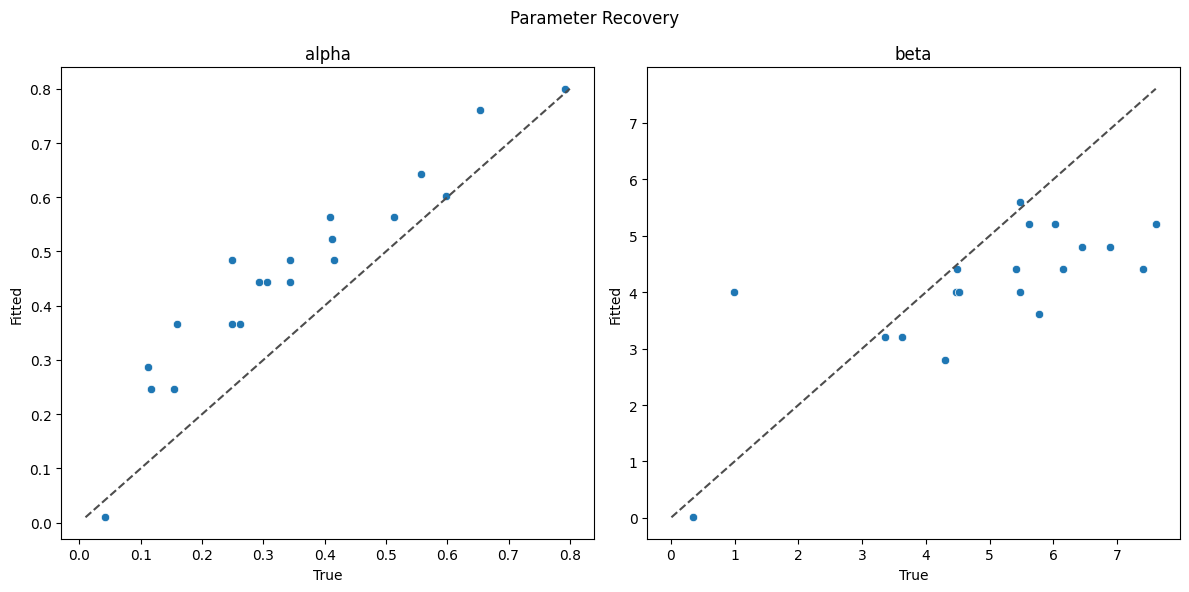

Correlation between alpha and beta: 0.189, p-value: 0.425


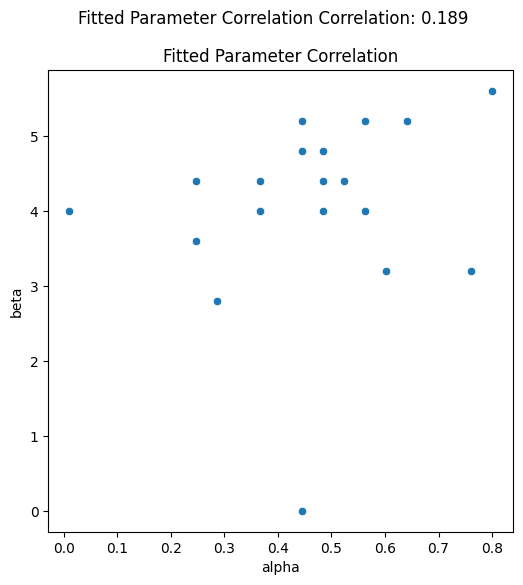

In [ ]:
# Plot true vs. fitted parameters
plot_param_recovery(true_params, fitted_params, title='Parameter Recovery')

# Plot correlation between fitted parameters (e.g., alpha & beta)
plot_param_correlation(fitted_params, title='Fitted Parameter Correlation')


### Interpretation

The Rescorla-Wagner model demonstrates strong reliability in recovering cognitive parameters. The learning rate shows excellent recovery, with a high Pearson correlation of **0.943** (p = 0.000), indicating that the model accurately estimates this parameter with minimal bias or error. The inverse temperature also exhibits a strong correlation of **0.739** (p = 0.000), though with slightly more variability in its recovery. Additionally, the correlation between the fitted learning rate and inverse temperature is **0.189** (p = 0.425), suggesting that these parameters are estimated independently, with no significant interdependence or systematic bias.

These results confirm that the model effectively recovers the cognitive parameters, particularly learning rate, while maintaining clear separation between the two estimates.


## **4.2. BRM Parameter Recovery (Simulated Data BRM)**

### **Set up a suitable space of parameters relevant for parameter recovery**  

This code block defines the parameter ranges and sampling methods used for recovering the best-fitting Bayesian RL model parameters through grid search and stochastic (random) search.

**Parameter Ranges:**
The following parameter ranges*are used, which match those used during the model simulation:
- **Inverse Temperature (`inv_temp`)**: Ranges from **0.1** to **10**.
- **Hazard Rate (`hazard_rate`)**: Ranges from **0.01** to **0.5**.

These ranges define the possible values over which the model will search during grid search and random sampling.

**Grid Search Space:**
To create a grid search over the parameter space, the following is used:
- Grid Resolution: The number of interpolation steps is set to **21**.
- This means the grid will include **21 evenly spaced points** between the minimum and maximum values for both `inv_temp` and `hazard_rate`.


In [ ]:
from scipy.stats import uniform
import numpy as np

# set random seed for reproducibility
np.random.seed(42)

# define parameter ranges for Bayesian RL model - same as for model fitting
INV_TEMP_RANGE = (0.1, 10)
HAZARD_RATE_RANGE = (0.01, 0.5)

INTERPOLATION_STEPS = 21 # grid search resolution (granularity)

# define grid search space
param_recovery_space_bayes = {
  'inv_temp': np.linspace(*INV_TEMP_RANGE, INTERPOLATION_STEPS),
  'hazard_rate': np.linspace(*HAZARD_RATE_RANGE, INTERPOLATION_STEPS)
}

# define parameter distributions for random sampling (stochastic search)
param_recovery_distributions_bayes = {
  'inv_temp': uniform(INV_TEMP_RANGE[0], INV_TEMP_RANGE[1] - INV_TEMP_RANGE[0]),
  'hazard_rate': uniform(HAZARD_RATE_RANGE[0], HAZARD_RATE_RANGE[1] - HAZARD_RATE_RANGE[0])
}

print("Initialized param_recovery_space_bayes:", param_recovery_space_bayes.keys())

Initialized param_recovery_space_bayes: dict_keys(['inv_temp', 'hazard_rate'])


### **Using the functions above to generate behavior from a models, for a given set of (randomly sampled) parameters, and then fit the model to its generated data, and evaluating the parameter fit in a quantiative manner.**


In this code block, we test the BRM model's ability to recover parameters by simulating behavior from randomly sampled true parameters and then fits it to recover those parameters using grid search. This process helps evaluate how well the model can recover parameters from simulated data.

**Parameters:**
- **agent_class**: The `BayesianRLModel` class used for simulations.
- **param_space**: The parameter search space for grid search, which includes possible values for the `inv_temp` and `hazard_rate`.
- **param_distributions**: A dictionary of distributions used to sample the true parameters for each simulation run.
- **num_participants**: Number of participants per simulation run.
- **num_trials**: Number of trials per participant.
- **num_runs**: Number of simulation runs for parameter recovery.
- **fixed_params**: A dictionary of fixed parameters, such as priors.

**Process:**
1. **Sampling True Parameters**: For each run, true parameters (e.g., `inv_temp`, `hazard_rate`) are randomly sampled using the provided distributions.
2. **Simulating Data**: For each participant:
   - A new agent is created using the true sampled parameters.
   - Simulated behavior is generated by computing expected values (`mu0`, `mu1`), applying a softmax decision rule, and using trial-specific reward probabilities.
   - The agent's beliefs are updated based on the chosen bandit and the received reward.
3. **Fitting the Model**: After simulating the data for all participants, the model is fit to the data using a grid search (`grid_search_bayes`) to recover the best-fitting parameters.
4. **Results**: The recovered parameters and log-likelihoods are stored and returned.

**Output:**
- **fitted_params**: A dictionary containing the recovered parameters for each simulation run.
- **true_params**: A dictionary containing the true parameters used in the simulation.
- **best_LLs**: Log-likelihoods for the best-fitting model in each simulation run.

In [ ]:
from tqdm import tqdm
import numpy as np
import pandas as pd

def param_recovery_bayes(agent_class, param_space, param_distributions, num_participants=11, num_trials=100, num_runs=20, fixed_params={'prior_alpha': 1, 'prior_beta': 1}):
    """
    Performs parameter recovery by simulating behavior for multiple participants using randomly sampled
    true parameters, then fitting the Bayesian RL model to recover these parameters using grid search.

    :param agent_class: The BayesianRLModel class.
    :param param_space: Parameter search space dictionary (for grid search).
    :param param_distributions: Dictionary of parameter distributions for true parameter sampling.
    :param num_participants: Number of participants per simulation run.
    :param num_trials: Number of trials per participant.
    :param num_runs: Number of simulation runs.
    :param fixed_params: Fixed parameters (priors) for the model.
    :return: Dictionaries of true parameters, recovered parameters, and log-likelihoods per run.
    """
    # storage for recovery results
    true_params = {param: [] for param in param_space.keys()}
    fitted_params = {param: [] for param in param_space.keys()}
    best_LLs = [] # log-likelihood for each run

    # loop over multiple runs
    for run in tqdm(range(num_runs), desc='Fitting Runs', total=num_runs, leave=True):
        # sample a set of true parameters for this run using uniform distributions
        sampled_params = {param: param_distributions[param].rvs() for param in param_space.keys()}

        # store true parameters
        for param in param_space.keys():
            true_params[param].append(sampled_params[param])

        # simulate behavior for all participants using the same true parameters
        all_choices = []
        all_rewards = []
        participant_ids = []

        # simulate each participant's data
        for p in range(num_participants):
            # create agent with sampled parameters
            agent = agent_class(prior_alpha=fixed_params['prior_alpha'],
                                prior_beta=fixed_params['prior_beta'],
                                inv_temp=sampled_params['inv_temp'],
                                hazard_rate=sampled_params['hazard_rate'])

            # simulate trials
            choices = []
            rewards = []
            for t in range(num_trials):
                # get current expected values (mu) from the agent
                (mu0, mu1), _ = agent.compute_values()

                # compute choice probabilities using softmax
                probs = agent.compute_choice_probabilities((mu0, mu1))

                # choose bandit (0 or 1) based on computed probabilities
                choice = np.random.choice([0, 1], p=probs)

                # reward probs
                if t < 50:
                    reward_prob = 0.8 if choice == 0 else 0.2  # Bandit 1 (0) → 80%, Bandit 2 (1) → 20%
                else:
                    reward_prob = 0.2 if choice == 0 else 0.8  # Reversal: Bandit 1 (0) → 20%, Bandit 2 (1) → 80%

                # generate reward (1 for reward, 0 for no reward)
                reward = 1 if np.random.rand() < reward_prob else 0

                # update agent beliefs
                agent.update_beliefs(choice, reward)

                # store choices and rewards
                choices.append(choice)
                rewards.append(reward)

            all_choices.extend(choices)
            all_rewards.extend(rewards)
            participant_ids.extend([p] * num_trials)

        # create df for the simulated data
        sim_data = pd.DataFrame({
            "participant": np.repeat(np.arange(num_participants), num_trials),
            "trial": np.tile(np.arange(num_trials), num_participants),
            "choice": all_choices,
            "reward": all_rewards
        })

        # fit the model to recover parameters using grid search
        best_params, best_LL = grid_search_bayes(agent_class, sim_data, param_space, fixed_params)

        # store recovered parameters
        for param in param_space.keys():
            if param in best_params: # ensure param exists in grid search output
                fitted_params[param].append(best_params[param])
            else:
                fitted_params[param].append(None)  # placeholder for missing values

        best_LLs.append(best_LL)

    return fitted_params, true_params, best_LLs

Finally, this code executes the `param_recovery_bayes` function to simulate participant behavior, recover parameters, and evaluate the model's performance.

A random seed (`42`) is set to ensure the results are reproducible across runs.
   
**Running Parameter Recovery**:
   - The `param_recovery_bayes` function is called with the following arguments:
     - **agent_class**: The Bayesian RL model class (`BayesianRLModel`) to be used for simulations.
     - **param_space**: The parameter search space for grid search (`param_recovery_space_bayes`).
     - **param_distributions**: The true parameter sampling distributions (`param_recovery_distributions_bayes`).
     - **num_participants**: The number of participants per run (set to 11).
     - **num_trials**: The number of trials each participant undergoes (set to 100).
     - **num_runs**: The number of parameter recovery runs (set to 20).

**Returned Values**:
   - **fitted_params_bayes**: The parameters recovered by fitting the Bayesian RL model to simulated data.
   - **true_params_bayes**: The true parameters used to simulate participant behavior.
   - **best_LLs**: The log-likelihoods of the best-fitting models for each recovery run.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# set random seed for reproducibility
np.random.seed(42)

# run Bayesian RL parameter recovery
fitted_params_bayes, true_params_bayes, best_LLs = param_recovery_bayes(
  agent_class=BayesianRLModel,
  param_space=param_recovery_space_bayes, # grid search space
  param_distributions=param_recovery_distributions_bayes, # true parameter sampling distributions
  num_participants=11,
  num_trials=100, # number of trials per participant
  num_runs=20 # number of parameter recovery runs
)

Fitting Runs:   0%|          | 0/20 [00:00<?, ?it/s]

DEBUG: Entered grid_search_bayes()
DEBUG: Received param_space keys: dict_keys(['inv_temp', 'hazard_rate'])



Grid Search (inv_temp):   0%|          | 0/21 [00:00<?, ?it/s]

Grid Search (hazard_rate):   0%|          | 0/21 [00:00<?, ?it/s]

Grid Search (hazard_rate):  10%|▉         | 2/21 [00:00<00:01, 16.47it/s]

Grid Search (hazard_rate):  19%|█▉        | 4/21 [00:00<00:01, 15.48it/s]

Grid Search (hazard_rate):  29%|██▊       | 6/21 [00:00<00:00, 15.36it/s]

Grid Search (hazard_rate):  38%|███▊      | 8/21 [00:00<00:00, 15.54it/s]

Grid Search (hazard_rate):  48%|████▊     | 10/21 [00:00<00:00, 15.42it/s]

Grid Search (hazard_rate):  57%|█████▋    | 12/21 [00:00<00:00, 15.00it/s]

Grid Search (hazard_rate):  67%|██████▋   | 14/21 [00:00<00:00, 14.87it/s]

Grid Search (hazard_rate):  76%|███████▌  | 16/21 [00:01<00:00, 15.23it/s]

Grid Search (hazard_rate):  86%|████████▌ | 18/21 [00:01<00:00, 15.52it/s]

Grid Search (hazard_rate):  95%|█████████▌| 20/21 [00:01<00:00, 15.68it/s]

                                                                          
Grid Search (inv_temp):   5%|▍       

DEBUG: Best parameters found: {'inv_temp': np.float64(4.555), 'hazard_rate': np.float64(0.5)}
DEBUG: Entered grid_search_bayes()
DEBUG: Received param_space keys: dict_keys(['inv_temp', 'hazard_rate'])



Grid Search (inv_temp):   0%|          | 0/21 [00:00<?, ?it/s]

Grid Search (hazard_rate):   0%|          | 0/21 [00:00<?, ?it/s]

Grid Search (hazard_rate):  10%|▉         | 2/21 [00:00<00:01, 15.68it/s]

Grid Search (hazard_rate):  19%|█▉        | 4/21 [00:00<00:01, 13.88it/s]

Grid Search (hazard_rate):  29%|██▊       | 6/21 [00:00<00:01, 14.70it/s]

Grid Search (hazard_rate):  38%|███▊      | 8/21 [00:00<00:00, 14.56it/s]

Grid Search (hazard_rate):  48%|████▊     | 10/21 [00:00<00:00, 13.79it/s]

Grid Search (hazard_rate):  57%|█████▋    | 12/21 [00:00<00:00, 14.38it/s]

Grid Search (hazard_rate):  67%|██████▋   | 14/21 [00:01<00:00, 12.80it/s]

Grid Search (hazard_rate):  76%|███████▌  | 16/21 [00:01<00:00, 13.57it/s]

Grid Search (hazard_rate):  86%|████████▌ | 18/21 [00:01<00:00, 14.18it/s]

Grid Search (hazard_rate):  95%|█████████▌| 20/21 [00:01<00:00, 14.57it/s]

                                                                          
Grid Search (inv_temp):   5%|▍       

...

DEBUG: Best parameters found: {'inv_temp': np.float64(6.039999999999999), 'hazard_rate': np.float64(0.3775)}
DEBUG: Entered grid_search_bayes()
DEBUG: Received param_space keys: dict_keys(['inv_temp', 'hazard_rate'])



Grid Search (inv_temp):   0%|          | 0/21 [00:00<?, ?it/s]

Grid Search (hazard_rate):   0%|          | 0/21 [00:00<?, ?it/s]

Grid Search (hazard_rate):  10%|▉         | 2/21 [00:00<00:01, 10.44it/s]

Grid Search (hazard_rate):  19%|█▉        | 4/21 [00:00<00:01, 12.54it/s]

Grid Search (hazard_rate):  29%|██▊       | 6/21 [00:00<00:01, 13.26it/s]

Grid Search (hazard_rate):  38%|███▊      | 8/21 [00:00<00:00, 13.45it/s]

Grid Search (hazard_rate):  48%|████▊     | 10/21 [00:00<00:00, 13.83it/s]

Grid Search (hazard_rate):  57%|█████▋    | 12/21 [00:00<00:00, 12.66it/s]

Grid Search (hazard_rate):  67%|██████▋   | 14/21 [00:01<00:00, 10.85it/s]

Grid Search (hazard_rate):  76%|███████▌  | 16/21 [00:01<00:00, 10.66it/s]

Grid Search (hazard_rate):  86%|████████▌ | 18/21 [00:01<00:00, 10.39it/s]

Grid Search (hazard_rate):  95%|█████████▌| 20/21 [00:01<00:00, 10.23it/s]

                                                                          
Grid Search (inv_temp):   5%|▍       

DEBUG: Best parameters found: {'inv_temp': np.float64(2.575), 'hazard_rate': np.float64(0.30400000000000005)}
DEBUG: Entered grid_search_bayes()
DEBUG: Received param_space keys: dict_keys(['inv_temp', 'hazard_rate'])



Grid Search (inv_temp):   0%|          | 0/21 [00:00<?, ?it/s]

Grid Search (hazard_rate):   0%|          | 0/21 [00:00<?, ?it/s]

Grid Search (hazard_rate):  10%|▉         | 2/21 [00:00<00:01, 12.60it/s]

Grid Search (hazard_rate):  19%|█▉        | 4/21 [00:00<00:01, 13.42it/s]

Grid Search (hazard_rate):  29%|██▊       | 6/21 [00:00<00:01, 13.51it/s]

Grid Search (hazard_rate):  38%|███▊      | 8/21 [00:00<00:00, 13.89it/s]

Grid Search (hazard_rate):  48%|████▊     | 10/21 [00:00<00:00, 14.04it/s]

Grid Search (hazard_rate):  57%|█████▋    | 12/21 [00:00<00:00, 13.62it/s]

Grid Search (hazard_rate):  67%|██████▋   | 14/21 [00:01<00:00, 13.89it/s]

Grid Search (hazard_rate):  76%|███████▌  | 16/21 [00:01<00:00, 13.87it/s]

Grid Search (hazard_rate):  86%|████████▌ | 18/21 [00:01<00:00, 14.09it/s]

Grid Search (hazard_rate):  95%|█████████▌| 20/21 [00:01<00:00, 13.88it/s]

                                                                          
Grid Search (inv_temp):   5%|▍       

DEBUG: Best parameters found: {'inv_temp': np.float64(2.08), 'hazard_rate': np.float64(0.42650000000000005)}


### **Plot the parameter recovery results for both models**  

In this code block, we **visualize the accuracy of Bayesian RL model parameter recovery** using two key plots:  

1. **True vs. Fitted Parameters (`plot_param_recovery`)**  
   - Compares **true vs. recovered values** for **inverse temperature (`inv_temp`) and hazard rate (`hazard_rate`)**.  
   - If recovery is good, points should align closely along the **identity line** (dashed).  
   - A **high Pearson correlation** indicates strong recovery, while lower values suggest estimation errors.  

2. **Correlation Between Fitted Parameters (`plot_param_correlation`)**  
   - Checks if **fitted `inv_temp` and `hazard_rate` are independent** or show systematic bias.  
   - A **low correlation** suggests that the model estimates them separately, while a **high correlation** may indicate interdependence.  

These plots **quantify the reliability of Bayesian RL model fitting**, ensuring it effectively recovers cognitive parameters.

Pearson correlation for inv_temp: 0.961, p-value: 0.000
Pearson correlation for hazard_rate: 0.757, p-value: 0.000


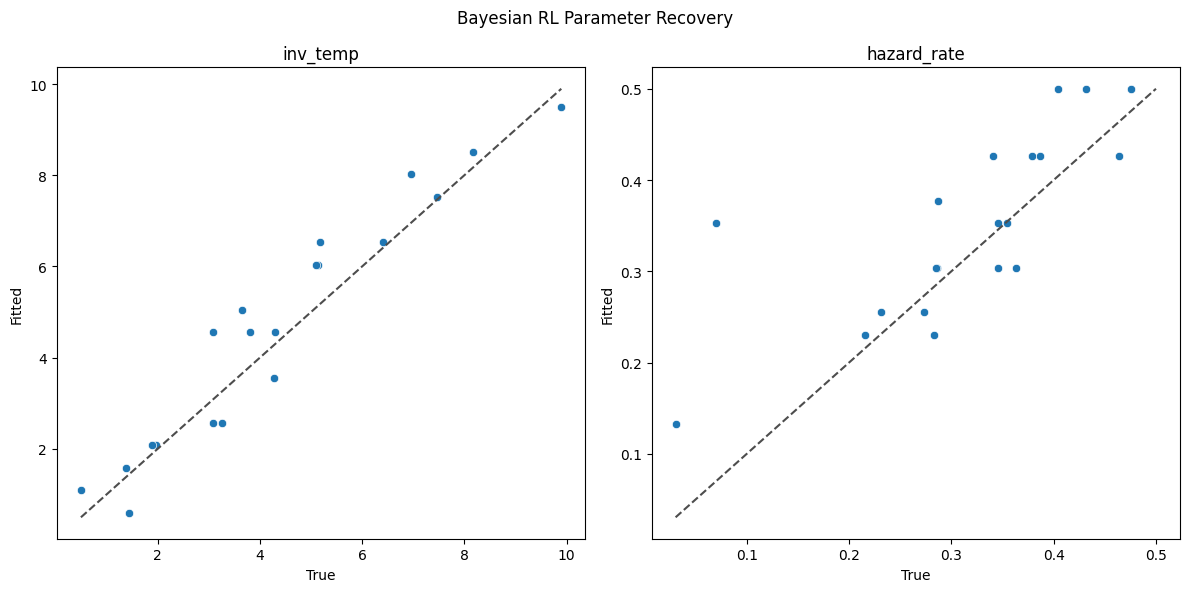

Correlation between inv_temp and hazard_rate: 0.075, p-value: 0.754


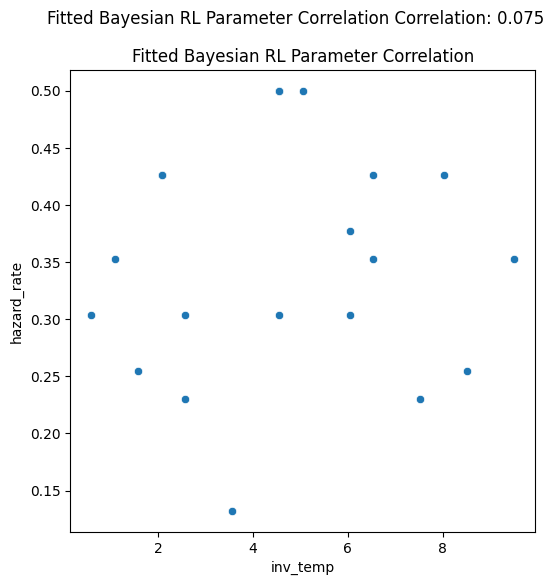

In [ ]:
plot_param_recovery(true_params_bayes, fitted_params_bayes, title='Bayesian RL Parameter Recovery')
plot_param_correlation(fitted_params_bayes, title='Fitted Bayesian RL Parameter Correlation')

### Interpretation
The Bayesian RL model demonstrates strong reliability in recovering cognitive parameters. The inverse temperature shows excellent recovery, with a high Pearson correlation of **0.961** (p = 0.000), indicating that the model accurately estimates this parameter with minimal bias or error. The hazard rate also exhibits a strong correlation of **0.757** (p = 0.000), though with slightly more variability in its recovery. Additionally, the correlation between the fitted inverse tempearture and hazard rate is **0.075** (p = 0.754)), suggesting that these parameters are estimated independently, with no significant interdependence or systematic bias.

These results confirm that the model effectively recovers the cognitive parameters, particularly inverse temperature, while maintaining clear separation between the two estimates.

## 4.3. Recovery Results Conclusion

Both the Bayesian RL model and the Rescorla-Wagner model demonstrate strong reliability in recovering cognitive parameters. Each model accurately estimates its key parameters with minimal bias. While some variability exists in the estimation of secondary parameters, both models maintain clear separation between their estimates, suggesting they effectively capture distinct cognitive processes. Additionally, the low correlation between fitted parameters in both models indicates that they estimate these parameters independently, without significant interdependence or systematic bias.

# **5. Model Recovery**

## **5.1. Visualizing Log-Likelihood Fit Across Parameter Space**

This function plots a heatmap of log-likelihood (LL) values across a two-dimensional parameter space (e.g., learning rate and inverse temperature). It helps visualize how well different parameter combinations fit the data.

- The function highlights the parameter values that maximize the LL.
- The heatmap shows the LL surface, giving insight into whether the model fit is sharp (well-identified) or flat (ambiguous).
- The color scale represents LL magnitude, and annotations indicate the best-fitting parameters.

This visualization aids in evaluating parameter recovery and understanding how sensitive the model is to parameter changes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fit_results(LL_results, parameter_space: dict, title=''):
    (param_1, param_1_space), (param_2, param_2_space) = parameter_space.items()

    fig, ax = plt.subplots(figsize=(10, 6))

    # Find best parameters
    max_ll_idx = np.unravel_index(np.argmax(LL_results, axis=None), LL_results.shape)
    max_ll = np.round(LL_results[max_ll_idx], 2)
    max_param_1 = np.round(param_1_space[max_ll_idx[0]], 2)
    max_param_2 = np.round(param_2_space[max_ll_idx[1]], 2)

    # Update title to include best-fit results
    title_with_results = f"{title}\nBest LL={max_ll}, {param_1}={max_param_1}, {param_2}={max_param_2}"
    fig.suptitle(title_with_results, fontsize=12)

    # Configure heatmap
    x_ticks = np.round(param_2_space, 3)
    y_ticks = np.round(param_1_space, 3)
    visible_ticks_x = [x_ticks[0], x_ticks[len(x_ticks) // 2], x_ticks[-1]]
    visible_ticks_y = [y_ticks[0], y_ticks[len(y_ticks) // 2], y_ticks[-1]]

    im = ax.imshow(LL_results, origin='lower', cmap='inferno')

    ax.set_xlabel(param_2)
    ax.set_xticks([0, len(x_ticks) // 2, len(x_ticks) - 1])
    ax.set_xticklabels(visible_ticks_x)
    ax.set_ylabel(param_1)
    ax.set_yticks([0, len(y_ticks) // 2, len(y_ticks) - 1])
    ax.set_yticklabels(visible_ticks_y)
    ax.set_title('Log Likelihoods')

    fig.colorbar(im, ax=ax, label='Log Likelihood')

    # Annotate the maximum log likelihood on the plot
    ax.annotate(f'Max LL={max_ll}\n{param_1}={max_param_1}, {param_2}={max_param_2}',
            xy=(max_ll_idx[1], max_ll_idx[0]),
            xytext=(max_ll_idx[1]+1, max_ll_idx[0]+1),
            arrowprops=dict(facecolor='darkgreen', shrink=0.005), color='darkgreen', zorder=10, textcoords='offset points')

    fig.tight_layout()
    plt.show()


## **5.2. RWM Model Recovery**

### **Fitting to itself**

This block evaluates whether the Rescorla-Wagner model can recover the parameters it was simulated with.

- Simulated using known values: `alpha = 0.1`, `beta = 2.0`.
- Trial data (`trial`, `choice`, `reward`) is extracted.
- Grid search is used to fit the model and find the best parameters.
- The recovered values are compared to the true ones.

A close match confirms the model’s ability to recover its own parameters, validating the fitting process.


In [ ]:
# To itself

# From the parameters in the simulation we set
alpha = 0.1     # Learning rate
beta = 2.0      # Inverse temperature parameter for Softmax

# Extract relevant columns for model fitting
RWM_data = simulated_df_RWM[["trial", "choice", "reward"]]

# Run grid search on the entire dataset to find the best overall parameters
best_params_RW_itself_recovery, LL_matrix_RW_itself_recovery = grid_search(RescorlaWagnerAgent, RWM_data, param_human_space)

# Print best-fit parameters
print("Best Alpha (learning rate):", best_params_RW_itself_recovery["alpha"])
print("Best Beta (inverse temperature):", best_params_RW_itself_recovery["beta"])

Grid Search (Alpha): 100%|██████████| 21/21 [00:31<00:00,  1.48s/it]

Best Alpha (learning rate): 0.2
Best Beta (inverse temperature): 1.585


### **Plotting Results (RWM to itself)**

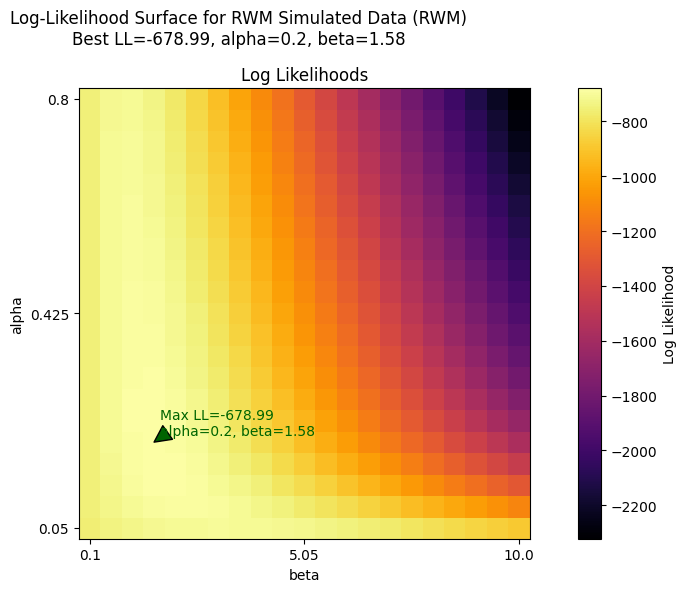

In [ ]:
plot_fit_results(LL_matrix_RW_itself_recovery, param_human_space, title="Log-Likelihood Surface for RWM Simulated Data (RWM)")

#### Interpretation

The Rescorla-Wagner model was fit its own simulated data. The best-fitting parameters were:

- **Learning rate**: α = 0.2 (true value: 0.2)
- **Inverse temperature**: β = 1.58 (true value: 2.0)
- **Maximum log-likelihood**: −678.99

The Rescorla-Wagner recovered reasonable estimates. There were only some slight discrepancies between the true and estimated values, which indicates potential biases in recovery. The learning rate was estimated perfectly! However, the inverse temperature was underestimated, implying a tendency to perceive decision-making as more exploratory than it actually was. Despite these differences, the model achieved a good overall fit.

### **Fitting to BRM**
We fit the Rescorla-Wagner model to data generated by the Bayesian model to assess cross-model parameter recovery.

- Extracted trial-level dat (only the needed columns).
- Performed grid search to find best-fitting `alpha` and `beta`.

This tests whether RWM can approximate behavior generated by a more complex model.

In [ ]:
# To BRM


# Extract relevant columns for model fitting
bayes_data = simulated_df_Bayes[["trial", "choice", "reward"]]

# Run grid search on the entire dataset to find the best overall parameters
best_params_RW_recovery, LL_matrix_RW_recovery = grid_search(RescorlaWagnerAgent, bayes_data, param_human_space)

# Print best-fit parameters
print("Best Alpha (learning rate):", best_params_RW_recovery["alpha"])
print("Best Beta (inverse temperature):", best_params_RW_recovery["beta"])

Grid Search (Alpha): 100%|██████████| 21/21 [00:39<00:00,  1.90s/it]

Best Alpha (learning rate): 0.38749999999999996
Best Beta (inverse temperature): 1.585


### **Plotting Results (RWM to BRM)**

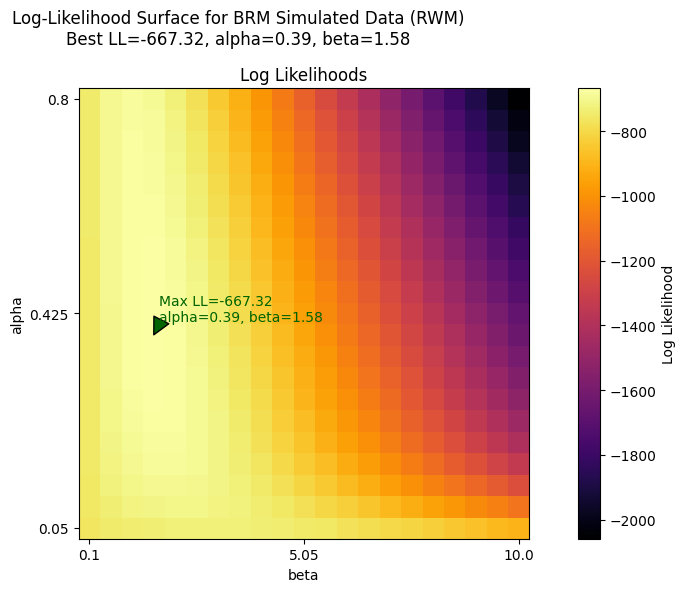

In [ ]:
plot_fit_results(LL_matrix_RW_recovery, param_human_space, title="Log-Likelihood Surface for BRM Simulated Data (RWM)")

#### Interpretation

The Rescorla-Wagner model was fit to data simulated by the Bayesian RL model. The best-fitting parameters were:

- **Learning rate**: α = 0.39
- **Inverse temperature**: β = 1.58
- **Maximum log-likelihood**: −667.32

The results indicate how well the simpler Rescorla-Wagner framework can adapt to more complex learning dynamics. The Rescorla-Wagner model showed a higher learning rate and inverse temperature compared to the values typically seen in the Bayesian model's own fitting. These differences reflect the Rescorla-Wagner model’s tendency to estimate parameters based on a more straightforward learning process, which may not fully capture the nuanced belief updating and decision-making processes of the Bayesian model.

The log-likelihood value achieved by the Rescorla-Wagner model was somewhat higher than the Bayesian model's fit to its own data (see 5.2), indicating a less optimal fit but still suggesting that the Rescorla-Wagner model could approximate some of the Bayesian model’s behavior, albeit with some approximation errors. This comparison highlights the flexibility of the Rescorla-Wagner model in handling data generated by a more complex process but also points to its limitations in capturing the subtleties of Bayesian learning.

## **5.3. BRM Model Recovery**

### **Fit to itself**

We fit the Bayesian model to its own simulated data using grid search with fixed priors to confirm the model can recover its own parameters, like we did with the RWM model.

- Data: `trial`, `choice`, `reward`
- Fixed: `prior_alpha = 1`, `prior_beta = 1`
- Output: best `inv_temp` and `hazard`

In [ ]:
# Extract relevant columns for model fitting
brm_recovery_data = simulated_df_Bayes[["trial", "choice", "reward"]]

# Run grid search on the entire dataset to find the best overall parameters
best_params_brm, LL_matrix_brm = grid_search_bayes(agent_class=BayesianRLModel, data=brm_recovery_data,
                                                   param_space=param_human_space_bayes,
                                                   fixed_params={'prior_alpha': 1, 'prior_beta': 1})

DEBUG: Entered grid_search_bayes()
DEBUG: Received param_space keys: dict_keys(['inv_temp', 'hazard_rate'])


Grid Search (inv_temp): 100%|██████████| 21/21 [00:45<00:00,  2.15s/it]

DEBUG: Best parameters found: {'inv_temp': np.float64(3.07), 'hazard_rate': np.float64(0.18150000000000002)}


In [ ]:
# Print best-fit parameters
print(f"Best Inverse Temperature (inv_temp): {best_params_brm['inv_temp']} (True: {inv_temp})")
print(f"Best Hazard Rate: {best_params_brm['hazard_rate']} (True: {hazard_rate})")

Best Inverse Temperature (inv_temp): 3.07 (True: 3)
Best Hazard Rate: 0.18150000000000002 (True: 0.15)


### **Plot Results (BRM to itself)**

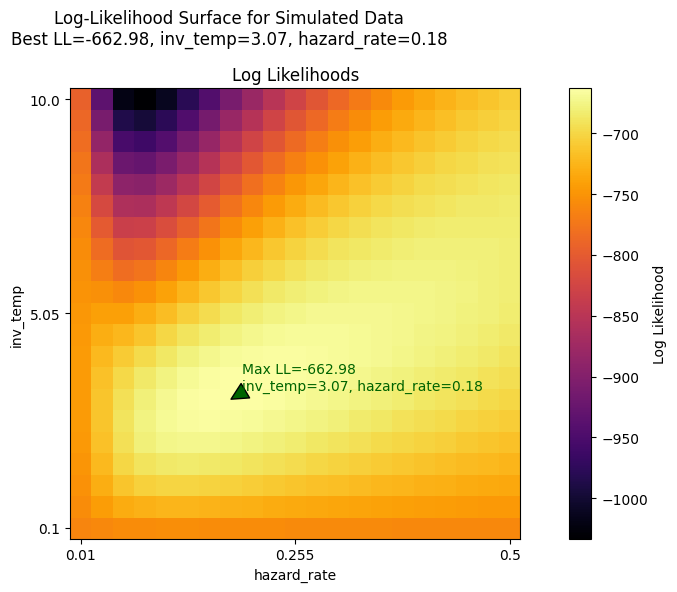

In [ ]:
plot_fit_results(LL_matrix_brm, param_human_space_bayes, title="Log-Likelihood Surface for Simulated Data")

#### Interpretation

The Bayesian RL model was fit its own simulated data. The best-fitting parameters were:

- **Inverse temperature**: 3.07 (true value: 3)
- **Hazard rate**: 0.18 (true value: 0.15)
- **Maximum log-likelihood**: −662.98

The recovered parameter estimates align closely with the true values. The inverse temperature was slightly overestimated, suggesting the model inferred a somewhat higher sensitivity to reward differences than was actually present in the data. Similarly, the hazard rate was slightly overestimated, indicating the model perceived environmental changes as occurring more frequently than they truly did. Despite these small discrepancies, the model achieved a strong overall fit, as reflected in its log-likelihood value. These results suggest that the Bayesian RL model effectively captures the underlying learning dynamics while maintaining reliable parameter recovery.

### **Fit to RWM**

In the following code block, we fit the Bayesian model to data generated by the Rescorla-Wagner model using grid search with fixed priors.

- Data: `trial`, `choice`, `reward`
- Fixed priors: `prior_alpha = 1`, `prior_beta = 1`
- Goal: assess whether the Bayesian model can capture behavior generated by a simpler, model-free agent.

This tests the flexibility and generalizability of the Bayesian model.


In [ ]:
# Extract relevant columns for model fitting
brm_recovery_RW = simulated_df_RWM[["trial", "choice", "reward"]]

fixed_params={'prior_alpha': 1, 'prior_beta': 1}

# Run grid search on the entire dataset to find the best overall parameters
best_params_brm_RW, LL_matrix_brm_RW = grid_search_bayes(agent_class=BayesianRLModel, data=brm_recovery_RW,
                                                   param_space=param_human_space_bayes,
                                                   fixed_params={'prior_alpha': 1, 'prior_beta': 1})

DEBUG: Entered grid_search_bayes()
DEBUG: Received param_space keys: dict_keys(['inv_temp', 'hazard_rate'])


Grid Search (inv_temp): 100%|██████████| 21/21 [00:43<00:00,  2.07s/it]

DEBUG: Best parameters found: {'inv_temp': np.float64(2.575), 'hazard_rate': np.float64(0.0835)}


### **Plot Results (BRM to RWM)**

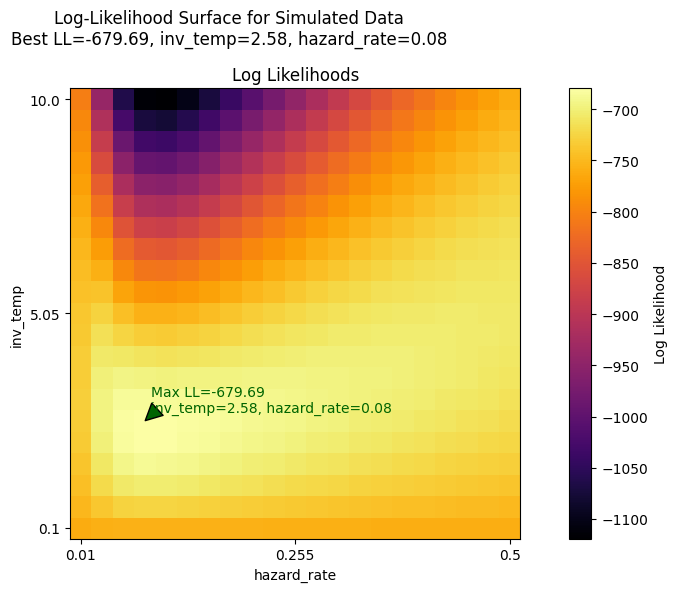

In [ ]:
plot_fit_results(LL_matrix_brm_RW, param_human_space_bayes, title="Log-Likelihood Surface for Simulated Data")

#### Interpretation

The Bayesian RL model was fit to data simulated by the Rescorla-Wagner model. The best-fitting parameters were:

- **Inverse temperature**: 2.58
- **Hazard rate**: 0.08
- **Maximum log-likelihood**: −679.69

The model demonstrates flexibility and adaptability in capturing the dynamics of the simpler Rescorla-Wagner process. The model’s parameter estimates indicate that it adjusted its parameters to mimic the behavior of the Rescorla-Wagner model, with a moderate inverse temperature reflecting moderately deterministic choices and a relatively low hazard rate, suggesting minimal belief drift, consistent with the stationary nature of the Rescorla-Wagner update mechanism.

Although the Bayesian model’s log-likelihood is slightly lower than that of the Rescorla-Wagner model, the results are remarkably similar, indicating that the Bayesian model was able to approximate the Rescorla-Wagner dynamics effectively.

This demonstrates the Bayesian model's ability to generalize and fit different types of learning processes, even those with simpler dynamics.

## 5.4. Conclusion on Model Recovery

The comparisons between the Bayesian RL model and the Rescorla-Wagner model highlight that the two models are functionally distinguishable, with their internal assumptions leading to clearly different behavior patterns. The Bayesian model, with its more complex belief updating and hazard rate parameters, tends to recover values that reflect a more flexible and dynamic learning process, while the Rescorla-Wagner model relies on simpler mechanisms.

Despite these differences, both models show the ability to fit simulated data generated by the other, demonstrating their adaptability and generalizability. These results support the validity of the modeling approach, as they confirm that the models can be identified through behavioral data. They can distinguish between distinct cognitive processes.

The findings suggest that, while both models are capable of capturing certain aspects of learning behavior, their unique underlying assumptions lead to detectably different results. Therefore, we can use these models to see which behavioral type fits the human data more accurately.

# **6. Model Comparison**

## **6.1. RWM Fit to Participant Data**

### **Load and (potentially) preprocess the experimental data.**

Already completed in the beginning of this document.

### **Fit the model to the data**  



In this code block, we **fit the Rescorla-Wagner model to human behavioral data** to estimate the **best-fitting parameters** that explain observed choices.  

**Key Steps:**  
1. **Extract relevant data** → Selects only **trial, choice, and reward** columns for fitting.  
2. **Run grid search** → Searches for the **optimal α (learning rate) and β (inverse temperature)** that maximize log-likelihood on the human dataset.  
3. **Identify best-fit parameters** → Prints the **α and β values** that best describe human decision-making patterns.  

If the model fits well, the recovered **α and β should provide insights into participants' learning and behavior** in the task.

In [ ]:
# Extract relevant columns for model fitting
human_data = full_dataset[["trial", "choice", "reward"]]

# Run grid search on the entire dataset to find the best overall parameters
best_params_human, LL_matrix_human = grid_search(RescorlaWagnerAgent, human_data, param_human_space)

Grid Search (Alpha): 100%|██████████| 21/21 [00:33<00:00,  1.57s/it]


In [ ]:
# Print best-fit parameters
print("Best Alpha (learning rate):", best_params_human["alpha"])
print("Best Beta (inverse temperature):", best_params_human["beta"])

Best Alpha (learning rate): 0.49999999999999994
Best Beta (inverse temperature): 3.07


### **Visualizing Model Fit Results**  



In this code block, we **plot the log-likelihood results** from the grid search to visualize **how well different parameter values fit the human data**.  

**Key Features of the Plot:**  
1. **Log-Likelihood Heatmap**  
   - Displays how **different α (learning rate) and β (inverse temperature) values** influence model fit.  
   - Darker colors indicate **lower likelihoods**, while brighter regions show **better fits**.  

2. **Optimal Parameter Annotation**  
   - Identifies and **annotates the best-fitting parameters** on the plot.  
   - The highest log-likelihood value is marked, showing the **optimal α and β** for human behavior.  

3. **Interpretation**  
   - A **clear peak** in log-likelihood suggests that **the model fits well** within the chosen parameter space.  
   - If the heatmap is **flat or noisy**, it may indicate **parameter uncertainty or poor model fit**.  

This visualization provides **an intuitive way to assess model fitting quality**, helping confirm whether the estimated parameters accurately capture **human decision-making behavior**.

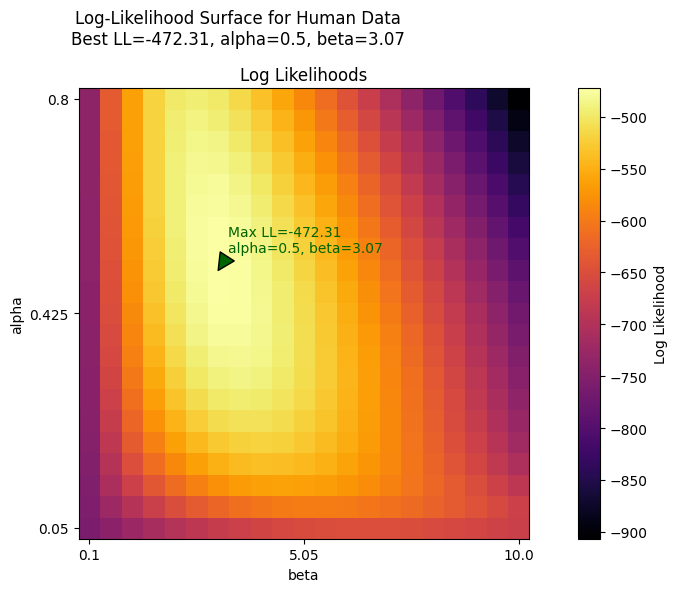

In [ ]:
 plot_fit_results(LL_matrix_human, param_human_space, title="Log-Likelihood Surface for Human Data")


## **6.2. BRM Fit to Participant Data**

### **Fit the model to the data**  



In this code block, we **fit the Bayesian reinforcement learning model to human behavioral data** to estimate the **best-fitting parameters** that explain observed choices.  

We run **grid search**, which searches for the **optimal inverse temperature and hazard rate** that maximize log-likelihood on the human dataset.   Then we print **the best-fitting parameters**.

If the model fits well, the recovered parameters would provide insights into participants' l**earning and behavior** in the task.

In [ ]:
# Run grid search on the entire dataset to find the best overall parameters
best_params_human_brm, LL_matrix_human_brm = grid_search_bayes(agent_class=BayesianRLModel, data=human_data,
                                                   param_space=param_human_space_bayes,
                                                   fixed_params={'prior_alpha': 1, 'prior_beta': 1})

DEBUG: Entered grid_search_bayes()
DEBUG: Received param_space keys: dict_keys(['inv_temp', 'hazard_rate'])


Grid Search (inv_temp): 100%|██████████| 21/21 [00:36<00:00,  1.74s/it]

DEBUG: Best parameters found: {'inv_temp': np.float64(8.02), 'hazard_rate': np.float64(0.2305)}


In [ ]:
# Print best-fit parameters
print("Best Inverse Temperature (inv_temp):", best_params_human_brm["inv_temp"])
print("Best Hazard Rate:", best_params_human_brm["hazard_rate"])

Best Inverse Temperature (inv_temp): 8.02
Best Hazard Rate: 0.2305


### **Visualizing Model Fit Results**  

We plot the log-likelihood results from the grid search to visualize how well different parameter values fit the human data, just like with the RWM.

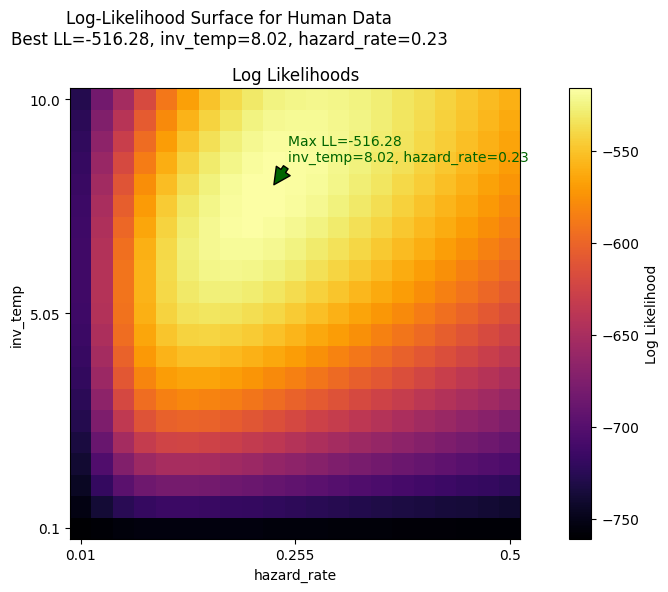

In [ ]:
plot_fit_results(LL_matrix_human_brm, param_human_space_bayes, title="Log-Likelihood Surface for Human Data")

## **6.3. Evaluate which model performs better, taking into account fit and model complexity.**

### **Defining Model Comparison Method: BIC**  

We compare the fit of the Rescorla-Wagner and Bayesian RL models to human behavioral data using the **Bayesian Information Criterion (BIC)**. This criterion balances model fit (log-likelihood) with complexity (number of free parameters), preventing overfitting.

The BIC is computed as:

$$
\text{BIC} = k \cdot \ln(n) - 2 \cdot \ln(\hat{L})
$$

Where:
- $k$ is the number of free parameters  
- $n$ is the number of data points (total number of trials)  
- $\hat{L}$ is the maximum likelihood from model fitting

The model with the **lower BIC** is considered to provide a better overall fit to the data.

**Reference**:  
[Schwarz, G. (1978). *Estimating the dimension of a model*](https://doi.org/10.1214/aos/1176344136). *The Annals of Statistics, 6*(2), 461–464.


In [ ]:
def compute_bic(log_likelihood, n_trials, n_params):
    """
    Compute Bayesian Information Criterion (BIC)

    Parameters:
    - log_likelihood: float, the log-likelihood of the fitted model
    - n_trials: int, total number of trials (data points)
    - n_params: int, number of free parameters in the model

    Returns:
    - float: the BIC value
    """
    return n_params * np.log(n_trials) - 2 * log_likelihood

### **Running Model Comparison**


We use the maximum log-likelihoods from each model's grid search and compute their BIC values using the total number of trials. The model with the **lower BIC** provides a better overall explanation of the data, balancing fit and complexity.

The bar plot below compares the BIC scores of both models. The better-fitting model is highlighted in green.

Rescorla-Wagner BIC: 958.62
Bayesian RL BIC: 1046.56


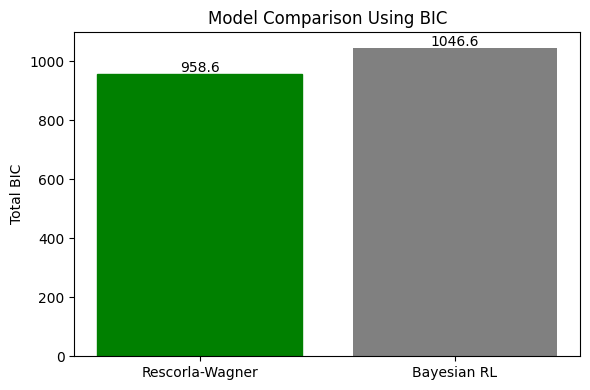

In [ ]:
# Get best log-likelihoods from grid search
best_ll_rw = np.max(LL_matrix_human)
best_ll_brm = np.max(LL_matrix_human_brm)

# Total number of trials in the dataset
n_trials = human_data.shape[0]

# Define number of parameters for each model
n_params_rw = 2        # alpha and beta
n_params_bayes = 2     # inv_temp and hazard_rate

# Compute BIC values
bic_rw = compute_bic(best_ll_rw, n_trials, n_params_rw)
bic_bayes = compute_bic(best_ll_brm, n_trials, n_params_bayes)

# Print BIC results
print(f"Rescorla-Wagner BIC: {bic_rw:.2f}")
print(f"Bayesian RL BIC: {bic_bayes:.2f}")

# Plot BICs
import matplotlib.pyplot as plt

models = ['Rescorla-Wagner', 'Bayesian RL']
bics = [bic_rw, bic_bayes]

plt.figure(figsize=(6, 4))
bars = plt.bar(models, bics, color=['gray', 'gray'])
bars[np.argmin(bics)].set_color('green')  # highlight best model

# Annotate BIC values on bars
for i, val in enumerate(bics):
    plt.text(i, val + 5, f'{val:.1f}', ha='center')

plt.title('Model Comparison Using BIC')
plt.ylabel('Total BIC')
plt.tight_layout()
plt.show()

## **6.4. Plot the behavior of the winning model against the data.**

### **Step 1: Implementing the Model with fitted parameters**

In the following code blocks, we simulate behavior using the **Rescorla-Wagner model**, which was identified as the best-fitting model based on the BIC comparison. The simulation uses the **best-fitting parameters (α and β)** obtained from fitting the model to human data. Similarly, for comparison's sake, we also simulate the best-fitting parameters (inverse temperature and hazard rate) from the Bayesian model. We use the **simulation code** as described in section 2.

The resulting DataFrames mirror the structure of the original dataset and is used to visually compare **model-generated behavior** to **actual human data** in the next step.


In [ ]:
print("Best fitting Rescorla-Wagner parameters")
print(best_params_human["alpha"])
print(best_params_human["beta"])

Best fitting Rescorla-Wagner parameters
0.49999999999999994
3.07


In [ ]:
# Simulate behavior using the Rescorla-Wagner agent for multiple participants using real human parameters

n_participants = 11
n_trials = 100  # Total number of trials in the simulation
alpha = best_params_human["alpha"] # Fitted rate
beta = best_params_human["beta"]   # Fitted Inverse temperature parameter for Softmax

# Storage for all participants
all_choices = []
all_rewards = []
all_Q_histories = []
participant_ids = []

# Run the model for each participant
for p in range(n_participants):
    # Create an agent instance
    agent = RescorlaWagnerAgent(alpha=alpha, beta=beta)

    # Run simulation
    sim_choices, sim_rewards, sim_Q_history = agent.simulate(n_trials=n_trials)

    # Store results
    all_choices.append(sim_choices)
    all_rewards.append(sim_rewards)
    all_Q_histories.append(sim_Q_history)
    participant_ids.extend([p] * n_trials)

# Convert lists to numpy arrays for easier processing
all_choices = np.array(all_choices).flatten()  # Shape: (11*100,)
all_rewards = np.array(all_rewards).flatten()  # Shape: (11*100,)
all_Q_histories = np.array(all_Q_histories)    # Shape: (11, 100, 2)

# Ensure trials are indexed from 1 to 100 for each participant
winning_simulated_df_RWM = pd.DataFrame({
    "participant_id": participant_ids,
    "trial": np.concatenate([np.arange(1, n_trials + 1) for _ in range(n_participants)]),  # Start trials at 1
    "choice": all_choices,
    "reward": all_rewards,
    "Q_Value_Bandit1": all_Q_histories[:, :, 0].flatten(),
    "Q_Value_Bandit2": all_Q_histories[:, :, 1].flatten()
})

# Print out the first few simulated choices and rewards
print("Simulated choices (first 10 trials of participant 1):",
      winning_simulated_df_RWM[winning_simulated_df_RWM["participant_id"] == 0]["choice"][:10].values)

print("Simulated rewards (first 10 trials of participant 1):",
      winning_simulated_df_RWM[winning_simulated_df_RWM["participant_id"] == 0]["reward"][:10].values)

# Display the first few rows of the DataFrame
print(winning_simulated_df_RWM)

Simulated choices (first 10 trials of participant 1): [1 0 0 1 0 0 0 1 1 0]
Simulated rewards (first 10 trials of participant 1): [0 0 1 0 1 1 0 1 0 0]
      participant_id  trial  choice  reward  Q_Value_Bandit1  Q_Value_Bandit2
0                  0      1       1       0         0.500000         0.250000
1                  0      2       0       0         0.250000         0.250000
2                  0      3       0       1         0.625000         0.250000
3                  0      4       1       0         0.625000         0.125000
4                  0      5       0       1         0.812500         0.125000
...              ...    ...     ...     ...              ...              ...
1095              10     96       1       1         0.128966         0.998776
1096              10     97       1       1         0.128966         0.999388
1097              10     98       0       0         0.064483         0.999388
1098              10     99       1       0         0.064483        

In [ ]:
# Simulate behavior using the Bayesian RL agent for multiple participants using real human parameters

import numpy as np
import pandas as pd

# simulation parameters
n_participants = 11
n_trials = 100 # number of trials
prior_alpha = 1
prior_beta = 1
inv_temp = best_params_human_brm["inv_temp"]
hazard_rate = best_params_human_brm["hazard_rate"]

# storage for all participants
all_choices = []
all_rewards = []
all_mu_histories = []
all_alpha_histories = []
all_beta_histories = []
participant_ids = []

# simulate behavior using Bayesian RL model
for p in range(n_participants):
  agent = BayesianRLModel(prior_alpha=prior_alpha, prior_beta=prior_beta, inv_temp=inv_temp, hazard_rate=hazard_rate)
  agent.reset() # ensure beliefs reset for each participant

  choices = []
  rewards = []
  mu_history = [] # track expected values
  alpha_history = []
  beta_history = []

  for t in range(n_trials):
    # compute expected values for both bandits
    (mu0, mu1), _ = agent.compute_values()

    # compute choice probabilities
    probs = agent.compute_choice_probabilities((mu0, mu1))

    # choose bandit based on probabilities
    choice = np.random.choice([0, 1], p=probs)

    # determine reward probability based on trial number (reverse at trial 50)
    if t < 50:
        reward_prob = 0.8 if choice == 0 else 0.2  # bandit 1: 80%, bandit 2: 20%
    else:
        reward_prob = 0.8 if choice == 1 else 0.2  # reversal point: bandit 1: 20%, bandit 2: 80%

    # assign reward & convert boolean to int
    reward = int(np.random.rand() < reward_prob)

    # store belief parameters (before updating)
    alpha_history.append([agent.alpha[0], agent.alpha[1]])
    beta_history.append([agent.beta[0], agent.beta[1]])

    # update beliefs based on choice and reward
    agent.update_beliefs(choice, reward)

    # store trial data
    choices.append(choice)
    rewards.append(reward)
    mu_history.append([mu0, mu1])

  # store participant data
  all_choices.append(choices)
  all_rewards.append(rewards)
  all_mu_histories.append(mu_history)
  all_alpha_histories.append(alpha_history)
  all_beta_histories.append(beta_history)
  participant_ids.extend([p] * n_trials)

# convert lists to numpy arrays
all_choices = np.array(all_choices).flatten()
all_rewards = np.array(all_rewards).flatten()
all_mu_histories = np.array(all_mu_histories)
all_alpha_histories = np.array(all_alpha_histories)
all_beta_histories = np.array(all_beta_histories)

# create df for Bayesian RL Model simulation
losing_simulated_df_Bayes = pd.DataFrame({
  "participant_id": participant_ids,
  "trial": np.concatenate([np.arange(1, n_trials + 1) for _ in range(n_participants)]),
  "choice": all_choices,
  "reward": all_rewards,
  "expected_value_0": all_mu_histories[:, :, 0].flatten(),
  "expected_value_1": all_mu_histories[:, :, 1].flatten(),
  "alpha_0": all_alpha_histories[:, :, 0].flatten(),
  "alpha_1": all_alpha_histories[:, :, 1].flatten(),
  "beta_0": all_beta_histories[:, :, 0].flatten(),
  "beta_1": all_beta_histories[:, :, 1].flatten(),
})

# print first 10 trials of participant 1
print("Simulated choices (first 10 trials of participant 1):",
  losing_simulated_df_Bayes[losing_simulated_df_Bayes["participant_id"] == 0]["choice"][:10].values)

print("Simulated rewards (first 10 trials of participant 1):",
  losing_simulated_df_Bayes[losing_simulated_df_Bayes["participant_id"] == 0]["reward"][:10].values)

print(losing_simulated_df_Bayes.head(10))

Simulated choices (first 10 trials of participant 1): [1 1 0 0 0 0 0 0 0 0]
Simulated rewards (first 10 trials of participant 1): [0 0 1 0 1 1 0 1 1 1]
   participant_id  trial  choice  reward  expected_value_0  expected_value_1  \
0               0      1       1       0          0.500000          0.500000   
1               0      2       1       0          0.500000          0.361076   
2               0      3       0       1          0.500000          0.297475   
3               0      4       0       0          0.638924          0.328108   
4               0      5       0       1          0.473618          0.356346   
5               0      6       0       1          0.582914          0.381618   
6               0      7       0       0          0.650748          0.403647   
7               0      8       0       1          0.522248          0.422410   
8               0      9       0       1          0.599180          0.438080   
9               0     10       0       1        

### **Step 2: Plotting the behaviour of the winning model against the data**

### **Plot 1: Behaviour of the winning Model (RWM)**

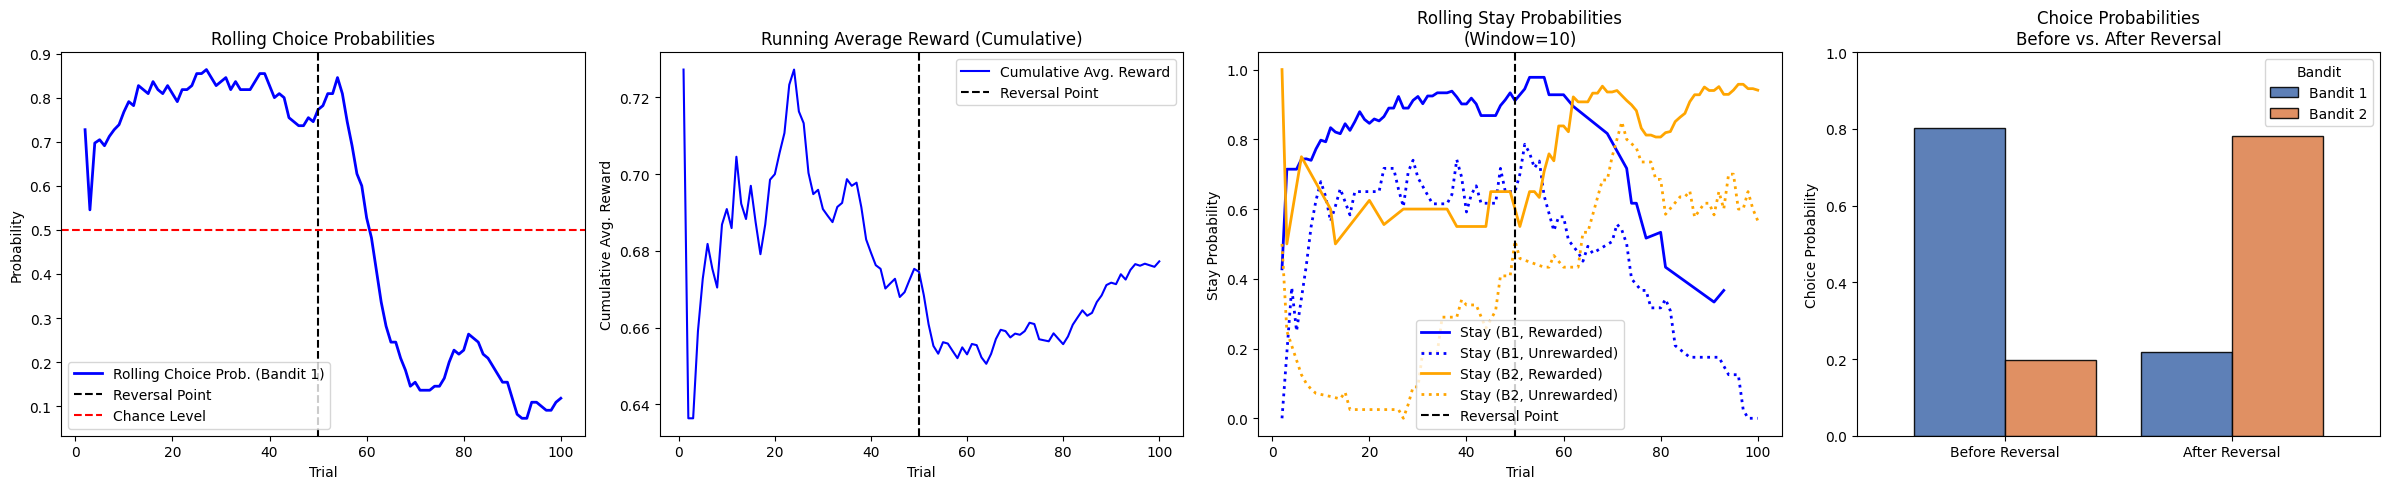

In [ ]:
plot_behaviour(winning_simulated_df_RWM)

### **Plot 2: Behaviour of the losing Model (BRM)**

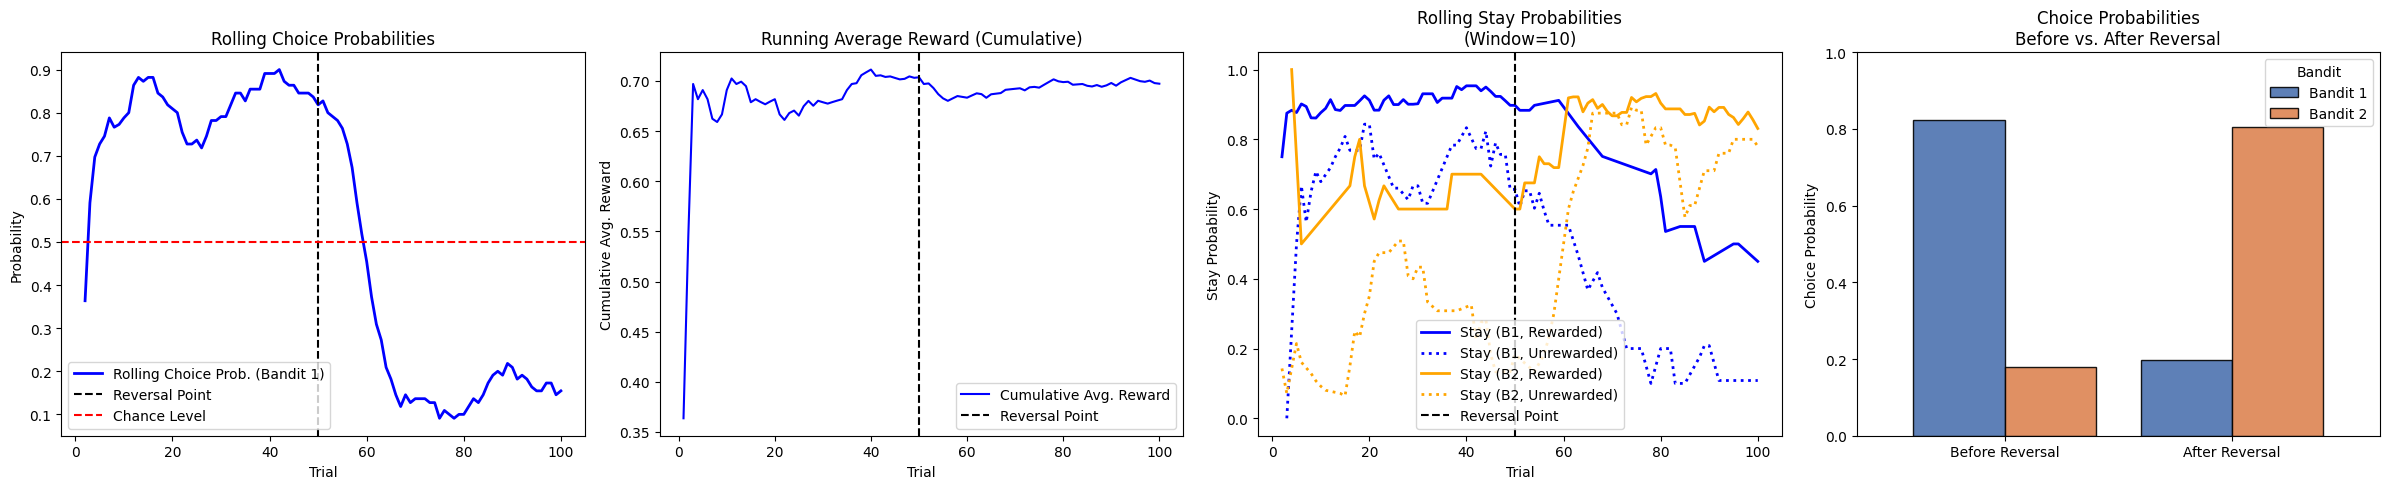

In [ ]:
plot_behaviour(losing_simulated_df_Bayes)

### **Plot 3: Behaviour of Human Data**

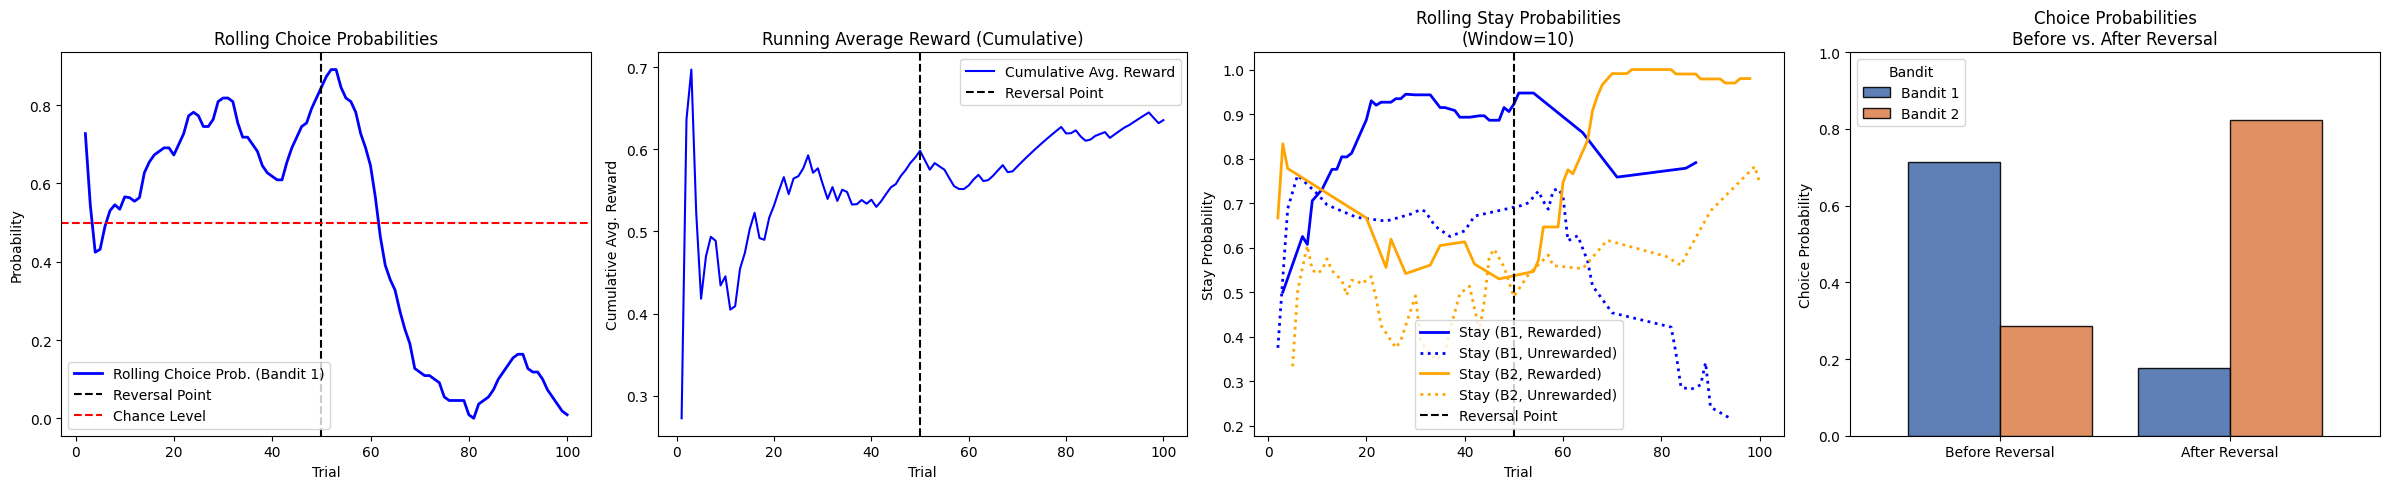

In [ ]:
plot_behaviour(full_dataset)

##References
Wilson, R. C., Collins, A. G. E. (2019). Ten simple rules for the computational modeling of behavioral data. eLife, 8, e49547. https://doi.org/10.7554/eLife.49547

Cools, R., Clark, L., Owen, A. M., Robbins, T. W. (2002). Defining the neural mechanisms of probabilistic reversal learning using event-related fMRI. NeuroImage, 17(1), 411–418. https://doi.org/10.1006/nimg.2002.1176

Daw, N. D., Gershman, S. J., Seymour, B., Dayan, P., Dolan, R. J. (2011). Model-based influences on humans’ choices and striatal prediction errors. Neuron, 69(6), 1204–1215. https://doi.org/10.1016/j.neuron.2011.02.027

Rescorla, R. A., Wagner, A. R. (1972). A theory of Pavlovian conditioning: Variations in the effectiveness of reinforcement and nonreinforcement. In A. H. Black W. F. Prokasy (Eds.), Classical Conditioning II: Current Research and Theory (pp. 64–99). Appleton-Century-Crofts.

Gershman, S. J. (2015). A unifying probabilistic view of associative learning. PLoS Computational Biology, 11(11), e1004567. https://doi.org/10.1371/journal.pcbi.1004567

 Nassar, M. R., Wilson, R. C., Heasly, B., & Gold, J. I. (2010). An approximately Bayesian delta-rule model explains the dynamics of belief updating in a changing environment. Journal of Neuroscience, 30(37), 12366–12378. https://doi.org/10.1523/JNEUROSCI.0822-10.2010

Erev, I., Ert, E., & Roth, A. E. (2010). A choice prediction competition for market entry games: An introduction. Games, 1(2), 117–136. https://doi.org/10.3390/g1020117
